# Le' Sean Roberts 

# CUNY City Tech Alumni (Graduate)

# Exploratory Development with UNICEF MICS Using Python

### March 21st, 2026

[Email](lesean.roberts85@gmail.com)

[LinkedIn](https://www.linkedin.com/in/le-sean-roberts)

[GitHub](https://github.com/LeSeanRoberts)

## Abstract

This development involves the exploration of Multiple Indicator Cluster Surveys (MICS) from the United Nations International Children's Emergency Fund (UNICEF) with the Python programming language. Surveys are among the world's largest and premier household survey programmes, specifically designed to collect statistically sound and internationally comparable data on the well-being of children and women. Often the comprehension and assimilation of data for such types of surveys towards data science interests can be challenging due to lack of routine exposure to the general public in daily life. This development involves premature exploratory tasks.  

## Introduction

Since its inception in 1995, UNICEF's MICS has evolved into a primary data source for monitoring the Sustainable Development Goals (SDGs), covering approximately 40% of household-based SDG indicators. Such has become the monumental source of statistically sound and internationally comparable data on children and women worldwide. MICS is an integral part of the plans and policies of many governments around the world.

MICS data is collected through face-to-face interviews using a modular questionnaire design. This allows countries to customize the survey to their specific needs while maintaining global comparability.

The standard set includes five main questionnaires:

1. Household Questionnaire: Focuses on living conditions, household members, education, and water/sanitation (WASH).

2. Women’s Questionnaire (ages 15–49): Covers fertility, maternal health, contraception, and attitudes toward domestic violence.

3. Men’s Questionnaire (ages 15–49): Often a subset of households, focusing on health, HIV/AIDS knowledge, and mass media use.

4. Children Under Five: Answered by mothers/caregivers; includes nutrition, immunization, and early childhood development.

5. Children & Adolescents (ages 5–17): Focuses on child labour, child functioning (disability), and foundational learning skills.

MICS is quite useful in data science—especially in the following fields:

1. Development Economics

2. Public Health

3. Climatology + Socio-economic Analysis

4. Policy Modelling

5. Survey Statistics / Causal Inference

Taken up is the challenge of comprehending and assimilating such data to develop exploratory models and analyses with Python as a beginner step for future advanced interests. Generally, the R environment is premier involving statistical development with MICS, since it is open source with a strong historical market for statistical development. Dedication and knowledge are crucial elements for strong development; well, such is the case for all promgramming or statistical languages. As a test case, applied is the Republic of Trinidad and Tobago MICS 2022 data. Will pursue stochastic, statistical and machine learning development. 

## Data Format and Structure

UNICEF MICS data is published in the form of .sav files. It is the native data format of IBM SPSS Statistics. It’s widely used by organisations like UNICEF for datasets. MICS datasets are complex survey datasets that include:

1. Variable labels (human-readable names)

2. Value labels (e.g., 1 = Male, 2 = Female)

3. Survey weights

4. Sampling design info (strata, clusters)

The .sav format preserves all of that metadata cleanly—much better than CSV or general spreadsheet orientation.

Data files are only available in SPSS format can be opened/converted by most recent versions of other statistical software.

The files involving Trinidad and Tobago MICS 2022 and other foreign places are genegeral six in total. Such are

1. hh.sav

       Households - including Water Quality Testing Questionnaire
2. hl.sav

       Household members

3. wm.sav

       Women (age 15-49 years)

4. bh.sav 

       Fertility/Birth history module (administered to women age 15-49 years)

5. ch.sav

       Children under five

6. fs.sav

       Children age 5-17 years

For more information on survey and sampling methodology such can found on the UNICEF MICS  general website. The standard data dictionary and standard SPSS syntax files for creation of background variables and tabulations of the Survey Findings Report are available at mics.unicef.org/tools. Survey datasets are made publicly available on behalf of the Central Statistical Office of Trinidad and Tobago.


The bh.sav dataset contains one row per child ever born to interviewed women (usually age 15–49). So instead of household-level or individual-level data, this is event-level (child-level) data.

The bh.sav file **SHOULD NOT** be treated like a flat dataset.

1. It is Hierarchical

2. Needs merging with women (wm.sav) and household (hh.sav)

**BH Identification Variables (linking keys)** - these connect to other datasets like household or women files:

HH1 → Cluster number

HH2 → Household number

LN → Line number of the woman (mother)

Such above variables permit merger with the Household file (hh.sav) and the Women file (wm.sav). 

**Century Month Code (CMC)**

Dates in MICS are often stored as CMC. Example:

    January 2000 = 1201

    Used for: Age calculations and Time-to-event models

**NOTICE: throughout this development, for all data there will be NO ASSUMPTION that Gaussian behaviour is present.**

## Data Assimilation

Assimilating and inspecting the files (of interest):

In [1]:
# Loading the basic libraries
import numpy as np
import pandas as pd
import pyreadstat

fertility_birth_story_df, bh_meta = pyreadstat.read_sav("bh.sav") # birth history
women_df, wm_meta = pyreadstat.read_sav("wm.sav")  # women
household_df, hh_meta = pyreadstat.read_sav("hh.sav")  # household

Inspecting the fertility and birth history data:

In [2]:
fertility_birth_story_df.info() # variable names

bh_codebook = pd.DataFrame({
    "variable": bh_meta.column_names,
    "label": bh_meta.column_labels
})
bh_codebook

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8267 entries, 0 to 8266
Data columns (total 49 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   HH1        8267 non-null   float64
 1   HH2        8267 non-null   float64
 2   LN         8267 non-null   float64
 3   WM1        8267 non-null   float64
 4   WM2        8267 non-null   float64
 5   WM3        8267 non-null   float64
 6   WMINT      8267 non-null   float64
 7   BH0        8267 non-null   float64
 8   BH2        8267 non-null   float64
 9   BH3        8267 non-null   float64
 10  BH4D       8267 non-null   float64
 11  BH4M       8267 non-null   float64
 12  BH4Y       8267 non-null   float64
 13  BH5        8267 non-null   float64
 14  BH6        8077 non-null   float64
 15  BH7        8077 non-null   float64
 16  BH8        8077 non-null   float64
 17  BH9U       190 non-null    float64
 18  BH9N       190 non-null    float64
 19  BH10       8267 non-null   float64
 20  BH4C    

,variable,label
0,HH1,Cluster number
1,HH2,Household number
2,LN,Line number
3,WM1,Cluster number
4,WM2,Household number
5,WM3,Woman's line number
6,WMINT,Interviewer number
7,BH0,Line Number
8,BH2,Twins
9,BH3,Sex of child


In [3]:
bh_meta.variable_value_labels # values for the variables

{'BH2': {1.0: 'SINGLE', 2.0: 'MULTIPLE', 9.0: 'NO RESPONSE'},
 'BH3': {1.0: 'BOY', 2.0: 'GIRL', 9.0: 'NO RESPONSE'},
 'BH4D': {99.0: 'NO RESPONSE'},
 'BH4M': {1.0: 'JANUARY',
  2.0: 'FEBRUARY',
  3.0: 'MARCH',
  4.0: 'APRIL',
  5.0: 'MAY',
  6.0: 'JUNE',
  7.0: 'JULY',
  8.0: 'AUGUST',
  9.0: 'SEPTEMBER',
  10.0: 'OCTOBER',
  11.0: 'NOVEMBER',
  12.0: 'DECEMBER',
  99.0: 'NO RESPONSE'},
 'BH4Y': {9999.0: 'NO RESPONSE'},
 'BH5': {1.0: 'YES', 2.0: 'NO'},
 'BH6': {99.0: 'NO RESPONSE'},
 'BH7': {1.0: 'YES', 2.0: 'NO'},
 'BH8': {0.0: 'NOT LISTED'},
 'BH9U': {1.0: 'DAYS', 2.0: 'MONTHS', 3.0: 'YEARS', 9.0: 'DK / NO RESPONSE'},
 'BH9N': {99.0: 'NO RESPONSE'},
 'BH10': {1.0: 'YES', 2.0: 'NO', 9.0: 'NO RESPONSE'},
 'BH4F': {1.0: 'Month and year',
  2.0: 'Month and age -y imp',
  3.0: 'Year and age - m imp',
  4.0: 'Y & age - y ignored',
  5.0: 'Year - a, m imp',
  6.0: 'Age - y, m imp',
  7.0: 'Month - a, y imp',
  8.0: 'None - all imp'},
 'BH9F': {0.0: 'No flag',
  1.0: '> interview',
  2.0: '<

In [4]:
print(fertility_birth_story_df.head(4)) # Showing first 4 rows fr each column

   HH1  HH2   LN  WM1  WM2  WM3  WMINT  BH0  BH2  BH3  ...  windex5  windex10  \
0  1.0  2.0  2.0  1.0  2.0  2.0   45.0  1.0  1.0  1.0  ...      3.0       6.0   
1  1.0  2.0  2.0  1.0  2.0  2.0   45.0  2.0  1.0  2.0  ...      3.0       6.0   
2  1.0  2.0  3.0  1.0  2.0  3.0   45.0  1.0  1.0  1.0  ...      3.0       6.0   
3  1.0  6.0  2.0  1.0  6.0  2.0   45.0  1.0  1.0  2.0  ...      2.0       3.0   

    wscoreu  windex5u  windex10u  wscorer  windex5r  windex10r  stratum  psu  
0  0.319969       3.0        6.0      NaN       NaN        NaN     11.0  1.0  
1  0.319969       3.0        6.0      NaN       NaN        NaN     11.0  1.0  
2  0.319969       3.0        6.0      NaN       NaN        NaN     11.0  1.0  
3 -0.441669       1.0        2.0      NaN       NaN        NaN     11.0  1.0  

[4 rows x 49 columns]


Inspecting the women data:

In [5]:
women_df.info() 
wm_codebook = pd.DataFrame({
    "variable": wm_meta.column_names,
    "label": wm_meta.column_labels
})

wm_codebook

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5895 entries, 0 to 5894
Columns: 390 entries, HH1 to psu
dtypes: float64(278), object(112)
memory usage: 17.5+ MB


,variable,label
0,HH1,Cluster number
1,HH2,Household number
2,LN,Line number
3,WM1,Cluster number
4,WM2,Household number
...,...,...
385,wscorer,Rural wealth score
386,windex5r,Rural wealth index quintile
387,windex10r,Rural wealth index decile
388,stratum,Sample strata


Inspecting the household data:

In [6]:
wm_meta.variable_value_labels # values for variables 

{'WM6M': {1.0: 'JANUARY',
  2.0: 'FEBRUARY',
  3.0: 'MARCH',
  4.0: 'APRIL',
  5.0: 'MAY',
  6.0: 'JUNE',
  7.0: 'JULY',
  8.0: 'AUGUST',
  9.0: 'SEPTEMBER',
  10.0: 'OCTOBER',
  11.0: 'NOVEMBER',
  12.0: 'DECEMBER'},
 'WM8': {1.0: 'YES, INTERVIEWED ALREADY', 2.0: 'NO, FIRST INTERVIEW'},
 'WM9': {1.0: 'YES', 2.0: 'NO / NOT ASKED'},
 'WM15C': {1.0: 'Yes', 2.0: 'No'},
 'WM15D': {1.0: 'Yes', 2.0: 'No phone'},
 'WM17': {1.0: 'COMPLETED',
  2.0: 'NOT AT HOME',
  3.0: 'REFUSED',
  4.0: 'PARTLY COMPLETED',
  5.0: 'INCAPACITATED (SPECIFY)',
  6.0: 'NO ADULT CONSENT FOR RESPONDENT AGE 15-17',
  96.0: 'OTHER (SPECIFY)'},
 'WM11': {1.0: 'YES, THE ENTIRE INTERVIEW WAS COMPLETED IN PRIVATE',
  2.0: 'NO, OTHERS WERE PRESENT DURING THE ENTIRE INTERVIEW (SPECIFY)',
  3.0: 'NO, OTHERS WERE PRESENT DURING PART OF THE INTERVIEW (SPECIFY)'},
 'WM12': {1.0: 'ENGLISH',
  2.0: 'SPANISH',
  3.0: 'MANDARIN',
  6.0: 'OTHER LANGUAGE (SPECIFY)'},
 'WM13': {1.0: 'ENGLISH', 2.0: 'SPANISH'},
 'WM14': {1.0: 'ENGLISH'

Inspecting the household data:

In [7]:
household_df.info() 

hh_codebook = pd.DataFrame({
    "variable": hh_meta.column_names,
    "label": hh_meta.column_labels
})

hh_codebook

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8969 entries, 0 to 8968
Columns: 306 entries, HH1 to psu
dtypes: float64(249), object(57)
memory usage: 20.9+ MB


,variable,label
0,HH1,Cluster number
1,HH2,Household number
2,HH3,Interviewer number
3,HH4,Supervisor number
4,HH5D,Day of interview
...,...,...
301,windex10u,Urban wealth index decile
302,wscorer,Rural wealth score
303,windex5r,Rural wealth index quintile
304,windex10r,Rural wealth index decile


In [8]:
hh_meta.variable_value_labels # values for variables

{'HH6': {1.0: 'URBAN', 2.0: 'RURAL'},
 'HH7': {1.0: 'North-West RHA',
  2.0: 'North-Central RHA',
  3.0: 'Eastern RHA',
  4.0: 'South-West RHA',
  5.0: 'Tobago RHA'},
 'HH8': {1.0: 'YES', 2.0: 'NO'},
 'HH9': {1.0: 'YES', 2.0: 'NO'},
 'HH10': {1.0: 'YES', 2.0: 'NO'},
 'HH12': {1.0: 'YES', 2.0: 'NO / NOT ASKED'},
 'HH14': {1.0: 'ENGLISH',
  2.0: 'SPANISH',
  3.0: 'MANDARIN',
  6.0: 'OTHER LANGUAGE (SPECIFY)'},
 'HH15': {1.0: 'ENGLISH', 2.0: 'SPANISH'},
 'HH16': {1.0: 'ENGLISH',
  2.0: 'SPANISH',
  3.0: 'MANDARIN',
  6.0: 'OTHER LANGUAGE (SPECIFY)'},
 'HH17': {1.0: 'YES, ENTIRE QUESTIONNAIRE',
  2.0: 'YES, PART OF QUESTIONNAIRE',
  3.0: 'NO, NOT USED'},
 'HH26B': {97.0: 'Inconsistent'},
 'HH33X$01': {1.0: 'YES, PERMISSION IS GIVEN',
  2.0: 'NO, PERMISSION IS NOT GIVEN'},
 'HH33X$02': {1.0: 'YES, PERMISSION IS GIVEN',
  2.0: 'NO, PERMISSION IS NOT GIVEN'},
 'HH33X$03': {1.0: 'YES, PERMISSION IS GIVEN',
  2.0: 'NO, PERMISSION IS NOT GIVEN'},
 'HH33X$04': {1.0: 'YES, PERMISSION IS GIVEN',
  

## Data Dictionary

### Part 1 — Commonly Underestimated Issues in MICS Data

#### 1. Complex Survey Design (CRITICAL)

MICS is not simple random sampling. It uses:

* Stratification (stratum)
* Clustering (psu)
* Sampling weights (wmweight, hhweight)

Implication:

* Standard ML/regression without adjustment → biased estimates
* Variance underestimated if clustering ignored

---

#### 2. Unit of Analysis Confusion

You have multiple levels:

* Household (hh.sav)
* Woman (wm.sav)
* Child/Birth (bh.sav)

Your bh dataset is:
→ One row per child ever born

Implication:

* Duplicates at household level are expected
* Merging incorrectly can inflate observations

---

#### 3. Categorical Variables Disguised as Numeric

Most variables are coded numerically:

* 1 = Yes
* 2 = No
* 9 = Missing / DK

Implication:

* Treating as numeric breaks models
* Must decode using metadata

---

#### 4. Missing Data Is NOT Random

Common patterns:

* Structural missing (e.g., age at death only if dead)
* Survey skip logic

Example:

* BH6, BH7 only for dead children

Implication:

* Cannot use naive imputation
* Must respect survey logic

---

#### 5. Century Month Code (CMC)

Dates stored as integers

Implication:

* Must convert before time analysis
* Errors here → wrong survival times

---

#### 6. Duplicate Labels / Repeated Columns

You saw repeated labels like:

* "Roster to check consent..."

Implication:

* Variable names matter more than labels
* Labels are not unique

---

#### 7. Weight Scaling

Weights are large integers

Correct usage:
wmweight / 1,000,000

---

#### 8. Subsample Variables

Urban/rural wealth variables:

* wscoreu, wscorer

Implication:

* Missing values are expected
* Do NOT treat as random missing

---

#### 9. Survival Bias

Birth history includes only:

* Women alive at survey

Implication:

* Underestimates mortality in some contexts

---

#### 10. Time Alignment Issues

You are mixing:

* Child birth year
* Survey year
* Household conditions at survey

Implication:

* Risk of reverse causality

---

## Basic Preliminary Data Wrangling For a Survival Analysis Structure

For BH9U (Age at death (unit)) and BH9N (Age at death (number)) the counts of non-missing data is too high compared to the other variables for any type of imputing to be meaningful. As well, such two variables are too socioeconomic and sociopolitically sensitive issues to crudely apply imputing schemes. 

Starting with a quick diagnostic:

**Identifying "Pseudo-Missing" Values**

Developing a missing code list that defines specific numbers that are standard placeholders in survey research.

Common placeholders for unknowns:

1. 8 / 98 / 998: Usually represent "Don't Know."

2. 9 / 99 / 999: Usually represent "Missing" or "Refused to answer."

3. The variation (9 vs 99 vs 999) depends on the "width" of the column (e.g., if a child's age is 2 digits, 99 is used).

The "Inconsistent" & "Other" Codes:

1. 7 (or 97, 997): Inconsistent. This is used when the respondent provided an answer that contradicts another part of the survey (e.g., saying a child is 5 years old but was born only 2 years ago).

2. 6 (or 96, 996): Other. This is used when the respondent gave an answer that didn't fit the pre-defined categories. While sometimes useful, in a numeric analysis of age or intervals, "Other" is often treated as missing.

By converting these codes to NaN, ensures that:

1. Math stays accurate: Pandas functions like .mean(), .sum(), and .std() automatically ignore NaN values, whereas they would have included 999 in the calculation, leading to massive errors.

2. Correct Visualization: When plotting, these "fake" high values won't create outliers on your charts.

3. Machine Learning Readiness: Most models cannot interpret 99 as a "missing value" and would treat it as a literal high quantity unless converted.

**Accounting for missing data designation:**

In [9]:
# Expanded MICS/DHS missing and special codes
# 6: Other, 7: Inconsistent, 8: Don't Know, 9: Missing/Refused
missing_codes = [
    6, 7, 8, 9,          # 1-digit fields
    96, 97, 98, 99,      # 2-digit fields
    996, 997, 998, 999   # 3-digit fields
]

fertility_birth_story_df = fertility_birth_story_df.replace(missing_codes, np.nan)

In [10]:
# Check outcome balance
fertility_birth_story_df["BH5"].value_counts()

BH5
1.0    8077
2.0     190
Name: count, dtype: int64

In [11]:
# Check death age consistency
fertility_birth_story_df[["BH9U", "BH9N"]].dropna().head()

# Unique instances
# Use single brackets to get a Series, then call unique()
u_values = fertility_birth_story_df["BH9U"].unique()
n_values = fertility_birth_story_df["BH9N"].unique()

In [12]:
u_values

array([nan,  1.,  3.,  2.])

In [13]:
n_values

array([nan,  2.,  1.,  5.,  0., 10., 19.,  3., 14., 15., 30., 16., 25.,
       21., 18., 11., 20., 13.,  4., 12., 17., 22., 26., 27.])

What BH9U and BH9N mean (MICS standard)

In UNICEF MICS:

    BH9N = numeric value of age at death

    BH9U = unit of that age

Units (BH9U):

| Code | Meaning |
| ---- | ------- |
| 1    | Days    |
| 2    | Months  |
| 3    | Years   |

Interpreting your sample:

| BH9U | BH9N | Meaning  |
| ---- | ---- | -------- |
| 1    | 2    | 2 days   |
| 3    | 7    | 7 years  |
| 2    | 1    | 1 month  |
| 2    | 5    | 5 months |

Observed is data with mixed units. 

**There's need for ONE consistent time unit (months is standard)**

Right now:

1. Some observations are in days

2. Some in months

3. Some in years

Convert to months (canonical):

In [14]:
def death_age_to_months(row):
    if pd.isna(row["BH9U"]) or pd.isna(row["BH9N"]):
        return None
    
    if row["BH9U"] == 1:      # days
        return row["BH9N"] / 30
    elif row["BH9U"] == 2:    # months
        return row["BH9N"]
    elif row["BH9U"] == 3:    # years
        return row["BH9N"] * 12
    else:
        return None

fertility_birth_story_df["death_age_months"] = fertility_birth_story_df.apply(
    death_age_to_months, axis=1
)

In [15]:
fertility_birth_story_df["death_age_months"].describe()

count    161.000000
mean      31.225880
std       75.477031
min        0.000000
25%        0.000000
50%        0.100000
75%        5.000000
max      360.000000
Name: death_age_months, dtype: float64

Concerning alive or dead children (BH5).....Why BH9U / BH9N are missing for living children

In UNICEF MICS birth history:

1. BH9U (+) BH9N = age at death

2. These are only recorded if the child has died

| Child status | BH9U / BH9N           |
| ------------ | --------------------- |
| Dead         | Filled (age at death) |
| Alive        | **Missing (NaN)**     |

If a child is still alive, they don’t have an "age at death" yet, so the dataset (should) correctly leaves it blank.

Children greater than 5 years usually shouldn’t be in under-5 analysis. For 'death_age_months', checking the following condition, should result in values greater than 120. Check the results in the 'death_age_months' column:

In [16]:
print(fertility_birth_story_df[
    fertility_birth_story_df["death_age_months"] > 120
])

        HH1   HH2   LN    WM1   WM2  WM3  WMINT  BH0  BH2  BH3  ...  windex10  \
459    37.0  12.0  1.0   37.0  12.0  1.0   91.0  4.0  1.0  1.0  ...       3.0   
843    69.0   1.0  2.0   69.0   1.0  2.0   92.0  2.0  1.0  1.0  ...       5.0   
866    70.0  15.0  2.0   70.0  15.0  2.0   45.0  1.0  1.0  2.0  ...       5.0   
876    71.0   2.0  1.0   71.0   2.0  1.0   92.0  1.0  1.0  1.0  ...       1.0   
878    71.0   2.0  1.0   71.0   2.0  1.0   92.0  3.0  1.0  1.0  ...       1.0   
879    71.0   2.0  1.0   71.0   2.0  1.0   92.0  4.0  1.0  1.0  ...       1.0   
1562  107.0  18.0  1.0  107.0  18.0  1.0   52.0  2.0  1.0  1.0  ...       2.0   
1715  116.0  15.0  2.0  116.0  15.0  2.0   65.0  1.0  1.0  1.0  ...       5.0   
1917  128.0   3.0  1.0  128.0   3.0  1.0   54.0  2.0  1.0  1.0  ...       5.0   
2028  133.0   NaN  1.0  133.0   NaN  1.0   54.0  1.0  1.0  1.0  ...       3.0   
2072  134.0  18.0  2.0  134.0  18.0  2.0   51.0  2.0  1.0  2.0  ...       5.0   
2075  134.0  18.0  2.0  134.

An event will be a deceased child:

Final duration variable:

**Duration: Time Elapsed between Birth and Death**

To define a "duration" variable for mortality analysis, to calculate the total time elapsed between the child's birth and their death (or the interview date if they are still alive).

In demographic surveys, BH9C (Age at death in months) is usually the "gold standard" for children who have passed away. However, to create a robust duration variable that covers all records, the following logic applies:

Structuring the Variable --

1. If the child has died: Use the age at death (BH9C).

2. If the child is alive: Use their current age (Interview Date - Birth Date).

In [17]:
# Calculate months since birth for all children (Total potential duration)
fertility_birth_story_df['months_since_birth'] = fertility_birth_story_df['WDOI'] - fertility_birth_story_df['BH4C']

# Define duration: 
# If child is NOT alive (BH5 != 1), use imputed death age (BH9C).
# If child IS alive, use the current age (months_since_birth).
fertility_birth_story_df['duration'] = np.where(
    fertility_birth_story_df['BH5'] != 1, 
    fertility_birth_story_df['BH9C'], 
    fertility_birth_story_df['months_since_birth']
)

In [18]:
# Summary statistics for months_since_birth
fertility_birth_story_df['months_since_birth'].describe()

count    8267.000000
mean      140.096045
std        87.919666
min         0.000000
25%        71.000000
50%       123.000000
75%       200.000000
max       442.000000
Name: months_since_birth, dtype: float64

In [19]:
# Summary statistics for durationabs
fertility_birth_story_df['duration'].describe()

count    8258.000000
mean      137.061637
std        88.887131
min         0.000000
25%        68.000000
50%       119.000000
75%       197.750000
max       442.000000
Name: duration, dtype: float64

**Demographic Standards for Children Age Groups Deaths**

**Neonatal** refers to the first 28 days of a baby's life (the newborn period), a critical time for adaptation to life outside the womb. Neonatal care, often provided in NICUs (Neonatal Intensive Care Units), focuses on managing high-risk issues like prematurity, infections, and birth complications. It covers specialized care, assessment, and support.

1. Neonatal mortality (<1 month)

2. Post-neonatal (1–11 months)

3. Child mortality (12–60 months)

4. If a child died but the age at death was never recorded or imputed, duration will be NaN.

In [20]:
# Function with ability to handle potential nulls
def age_group(m):
    if pd.isna(m):
        return "unknown"
    if m <= 1:
        return "neonatal"
    elif m <= 12:
        return "post_neonatal"
    else:
        return "child"

# Now apply your age_group function
fertility_birth_story_df["age_group_death"] = fertility_birth_story_df["duration"].apply(age_group)

In [21]:
# Summary statistics for age_group_death
fertility_birth_story_df['age_group_death'].describe()

count      8267
unique        4
top       child
freq       7866
Name: age_group_death, dtype: object

In [22]:
# Unique children death types
age_un = fertility_birth_story_df['age_group_death'].unique()
age_un

array(['child', 'post_neonatal', 'neonatal', 'unknown'], dtype=object)

**Creation of Mortality Events**

A binary variable where $1 = \text{Death}$ and $0 = \text{Censored (Alive)}$. You can create this from BH5

In [23]:
fertility_birth_story_df['event'] = np.where(fertility_birth_story_df['BH5'] != 1, 1, 0)

unique_events = fertility_birth_story_df['event'].unique()
unique_events

array([0, 1])

**Impossible Death Ages Sanity Check**

To perform this check, to compare the age at death with the time elapsed since birth. Since your dataset uses Century Month Code (CMC), the calculation is quite accurate because it converts dates into a continuous count of months.

An "impossible" record is one where the child is reported to have died at an age (in months) that exceeds the total number of months between their birth and the interview date.

The Logic --

1. Total Potential Life: Calculate $WDOI (Interview Date) - BH4C (Birth Date)$. This is the maximum number of months the child could have possibly lived.

2. Reported Life: Use BH9C (Imputed age at death in months).

3. The Conflict: If $BH9C > (WDOI - BH4C)$, the data is inconsistent.

In [24]:
# 1. Calculate the maximum possible age in months at the time of interview
fertility_birth_story_df['max_possible_months'] = fertility_birth_story_df['WDOI'] - fertility_birth_story_df['BH4C']

# 2. Identify 'Impossible' deaths
# We only check records where the child is not alive (BH5 != 1) 
# and we have a death age (BH9C)
impossible_deaths = fertility_birth_story_df[
    (fertility_birth_story_df['BH5'] != 1) & 
    (fertility_birth_story_df['BH9C'] > fertility_birth_story_df['max_possible_months'])
]

# 3. Output the results
if not impossible_deaths.empty:
    print(f"Alert: Found {len(impossible_deaths)} inconsistent records.")
    print(impossible_deaths[['HH1', 'HH2', 'LN', 'BH4C', 'WDOI', 'BH9C', 'max_possible_months']].head())
else:
    print("Data Check Passed: No children were reported dead after the interview date.")

Data Check Passed: No children were reported dead after the interview date.


**Sanity Check for Woman's Sample Weight**

In [25]:
# Check weights
fertility_birth_story_df["wmweight"].describe()

count    8267.000000
mean        0.793118
std         1.013291
min         0.038587
25%         0.215854
50%         0.388123
75%         0.812660
max        12.296981
Name: wmweight, dtype: float64

Based on the summary statistics provided, the minimum value of 0.038587 for 'wmweight' makes sense, provided that this variable represents a sampling weight.

In datasets related to fertility and birth histories (such as the UNICEF Multiple Indicator Cluster Surveys (MICS) or the Demographic and Health Surveys (DHS)), 'wmweight' specifically stands for "Woman’s Weight." 

What a Weight of 0.038 Represents --

Sampling weights are used to adjust for the survey design. A weight of $1.0$ means the respondent represents exactly one "average" person in the population.

1. Weights $< 1.0\,(Oversampling)$: A value of $0.038$ means this individual is from a group or region that was heavily oversampled. Specifically, they are being weighted at about $4\%$ of a "standard" respondent.

2. Why oversample? Researchers often oversample small regions or specific minority groups to ensure they have a large enough sample size ($n$) to make statistically significant conclusions about that sub-group. In a complex survey, it is common for a person in a tiny, over-surveyed province to have a very small weight.

The Distribution Context --

The rest of the summary statistics support the idea that these are normalized sampling weights:

1. The Mean $(0.793)$: In many surveys, weights are normalized so the mean is $1.0$ across the entire dataset. Since the mean is $0.793$, it suggests that fertility_birth_story_df is likely a subset of the original data (e.g., only women who have given birth). If the women who had births were more likely to come from oversampled regions, the average weight of this subset will naturally be less than $1.0$.

2. The Max $(12.29)$: This represents the opposite end—a woman from a group that was undersampled or had a very low response rate, meaning her single response represents about $12$ women in the actual population.

Connection to Your Data Structure --

In the context of a "birth story" dataset, this likely refers to a "pregnancy case" or a specific record in a woman's birth history. Since each birth is treated as an independent event for the purpose of fertility rates, the wmweight is applied to each of these "rows" to ensure the final birth rate calculations reflect the true population proportions.

In [26]:
print(fertility_birth_story_df['WDOI'])

0       1475.0
1       1475.0
2       1473.0
3       1473.0
4       1473.0
         ...  
8262    1472.0
8263    1472.0
8264    1472.0
8265    1473.0
8266    1473.0
Name: WDOI, Length: 8267, dtype: float64


#### Creating Merger Keys

MICS doesn’t always give a single ID—you construct it.

In [27]:
# Household ID
fertility_birth_story_df["hhid"] = fertility_birth_story_df["HH1"].astype(str) + "_" + fertility_birth_story_df["HH2"].astype(str)
women_df["hhid"] = women_df["HH1"].astype(str) + "_" + women_df["HH2"].astype(str)
household_df["hhid"] = household_df["HH1"].astype(str) + "_" + household_df["HH2"].astype(str)

# Woman ID (mother)
fertility_birth_story_df["wmid"] = fertility_birth_story_df["hhid"] + "_" + fertility_birth_story_df["LN"].astype(str)
women_df["wmid"] = women_df["hhid"] + "_" + women_df["LN"].astype(str)

#### Merging Data Sets

In [28]:
# Merge child (bh) with mother (wm)
merge_1 = fertility_birth_story_df.merge(women_df, on="wmid", how="left", suffixes=("", "_wm"))

# Merge with household
mics_data = merge_1.merge(household_df, on="hhid", how="left", suffixes=("", "_hh"))

In [29]:
mics_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8267 entries, 0 to 8266
Columns: 754 entries, HH1 to psu_hh
dtypes: float64(580), int64(1), object(173)
memory usage: 47.6+ MB


In [30]:
len(mics_data.columns)

754

In [31]:
mics_data.columns.tolist()[:200] # first 200 columns

['HH1',
 'HH2',
 'LN',
 'WM1',
 'WM2',
 'WM3',
 'WMINT',
 'BH0',
 'BH2',
 'BH3',
 'BH4D',
 'BH4M',
 'BH4Y',
 'BH5',
 'BH6',
 'BH7',
 'BH8',
 'BH9U',
 'BH9N',
 'BH10',
 'BH4C',
 'BH4F',
 'BH9C',
 'BH9F',
 'ListCat',
 'HH4',
 'HH6',
 'HH7',
 'WDOI',
 'WDOB',
 'BHLN',
 'ethnicity',
 'welevel',
 'insurance',
 'brthord',
 'magebrt',
 'birthint',
 'wmweight',
 'wscore',
 'windex5',
 'windex10',
 'wscoreu',
 'windex5u',
 'windex10u',
 'wscorer',
 'windex5r',
 'windex10r',
 'stratum',
 'psu',
 'death_age_months',
 'months_since_birth',
 'duration',
 'age_group_death',
 'event',
 'max_possible_months',
 'hhid',
 'wmid',
 'HH1_wm',
 'HH2_wm',
 'LN_wm',
 'WM1_wm',
 'WM2_wm',
 'WM3_wm',
 'WMINT_wm',
 'WM4',
 'WM5',
 'WM6D',
 'WM6M',
 'WM6Y',
 'WM8',
 'WM9',
 'WM15C',
 'WM15D',
 'WM17',
 'WM7H',
 'WM7M',
 'WM10H',
 'WM10M',
 'WM11',
 'WM12',
 'WM13',
 'WM14',
 'WM15',
 'WMHINT',
 'WMFIN',
 'WDOI_wm',
 'WB3M',
 'WB3Y',
 'WB4',
 'WB5',
 'WB6A',
 'WB6B',
 'WB7',
 'WB9',
 'WB10A',
 'WB10B',
 'WB11',
 '

In [32]:
[col for col in mics_data.columns if "_x" in col or "_y" in col]

[]

Observed are no duplicate columns from merge suffixes. So the 754 columns are not from merge conflicts—they are simply:

    All variables from BH + WM + HH combined

So, why 745 columns? Apparently...

| File               | Typical size |
| ------------------ | ------------ |
| BH (birth history) | 150–300 cols |
| WM (women)         | 200–400 cols |
| HH (household)     | 100–300 cols |


Identifying the significant variables:

In [33]:
# Number of columns for BH
sum(col.startswith("BH") for col in mics_data.columns)

29

In [34]:
# Number of columns for WM
sum(col.startswith("WM") for col in mics_data.columns)

77

In [35]:
# Number of columns for HH
sum(col.startswith("HH") for col in mics_data.columns)

151

Totals to about 257 just from selected prefixes.

The rest (~500) are likely:

1. constructed variables

2. weights / IDs

3. environment features

4. merge artifacts or unlabeled fields

The dataset is heavily dominated by household variables. This is very typical in MICS:

    HH modules are very detailed (assets, water, sanitation, etc.)

    Yet, most are irrelevant for mortality modelling

Now, to determine which variables to keep?

## Overview and Attributes for Survival Analysis 


### Survival Analysis

Survival analysis is a branch of statistics applied to analyse the expected duration of time until one or more events occur, such as the failure of a mechanical system, the death of a biological organism, or the departure of a customer (churn).

Unlike standard regression, survival analysis is uniquely equipped to manage censored data, which occurs when the event of interest has not happened for some subjects by the end of the observation period; (Hosmer et al, 2008) and (Collett, 2014).

**Core Concepts**

1. The Event and Time-to-Event

       The "event" (sometimes called a "failure") must be a binary transition from one state to another. Time-to-event is the duration from a defined baseline (e.g., the date of a medical diagnosis or the start of a machine's operation) to the occurrence of that event.

2. Censoring as the "missing data" problem inherent in time-to-event studies.

       Right-Censoring: The most common type. This happens if a study ends before the event occurs, or if a participant drops out. We know they survived at least until time $t$, but not how much longer.

       Left-Censoring: The event occurred before the subject entered the study, but it's unknown exactly when.

3. Survival analysis typically revolves around two mathematical functions:

Survival Function $S(t)$: The probability that a subject survives longer than time $t$. At $t=0$, $S(t)=1$, and it monotonically decreases toward 0 over time.

Hazard Function $\lambda(t)$: Also known as the "failure rate." It represents the instantaneous risk of the event occurring at time $t$, given that the subject has survived up until that point.

**Common Analytical Methods**

1. Kaplan-Meier Estimator

       This is a non-parametric statistic used to estimate the survival function from observed lifetime data (Kaplan and Meier, 1958). It is "non-parametric" because it doesn't assume a specific distribution (like a Bell Curve) for the data. It is often visualized as a "step function." It is excellent for comparing survival curves between two groups (e.g., Treatment A vs. Treatment B) using the Log-Rank Test to see if the differences are statistically significant.

2. Cox Proportional Hazards Model

       The Cox model (Cox, 1972) is a semi-parametric regression method used to explore the relationship between the survival of a patient and several explanatory variables (covariates).

       It estimates the Hazard Ratio (HR).

       An HR = 2 suggests that a specific group has twice the risk of the event occurring at any given time compared to the reference group.


**The Kaplan-Meier Estimator**

The survival probability at any specific time $t$ is calculated by multiplying the conditional probabilities of surviving all previous time intervals:

$$\hat{S}(t) = \prod_{t_i \le t} \left( 1 - \frac{d_i}{n_i} \right)$$

Breaking down the variables:

$n_i$: The number of subjects at risk just before time $t_i$ (those who haven't had the event yet and haven't been censored).

$d_i$: The number of events (e.g., deaths or failures) that occurred at time $t_i$.

$\frac{d_i}{n_i}$: The proportion of people who "failed" at that specific moment.

$(1 - \frac{d_i}{n_i})$: The proportion of people who "survived" that specific moment.

$\prod$: The product symbol, meaning we multiply these survival chunks together to get the cumulative probability.

**The Cox Proportional Hazards Model**

While Kaplan-Meier looks at survival over time, the Cox model looks at the hazard (the risk of the event happening) and how different factors (covariates) increase or decrease that risk.

The model is expressed by the hazard function $h(t)$:

$$h(t, X) = h_0(t) \exp(\sum_{i=1}^{p} \beta_i X_i)$$

Breaking down the variables:

$h_0(t)$: The baseline hazard. This is the risk of the event if all your predictors ($X$) are zero. It changes over time but is the same for everyone in the study.

$\exp(\dots)$: The exponential function ensures the hazard is always positive.

$\beta_i$: The coefficients. These tell you the "weight" or impact of each factor.

$X_i$: The covariates or predictors (e.g., age, weight, or whether a subject received a specific treatment).

The **most important part of this prior Cox math** is that $h_0(t)$ is separate from the predictors. This means the model assumes that the ratio of the hazard between two people stays constant over time. If a smoker is twice as likely to have a heart attack as a non-smoker at year 1, the model assumes they are also twice as likely at year 10.

To comprehend the Hazard Ratio (HR), we look at the coefficients ($\beta$) from the Cox model. The math follows a simple rule: the Hazard Ratio is the exponentiated coefficient, or $HR = e^\beta$.

$HR = 1$: No effect. The variable does not affect the risk. 

$HR > 1$: Increased risk. The event is more likely to happen. 

$HR < 1$: Decreased risk. The event is less likely to happen.

**A Concrete Example: Equipment Failure**

Imagine studying the "time until a water pump fails." There's one predictor variable:

Regular Maintenance ($X_1$), where $1$ means "Yes" and $0$ means "No."

If the model produces a coefficient $\beta = -0.693$:

1. Calculate the Hazard Ratio: $e^{-0.693} \approx 0.50$.

2. Interpretation: At any given time, a pump receiving regular maintenance is 50% less likely to fail than a pump without maintenance.

Alternatively, if we looked at High Pressure Usage ($X_2$) and found $\beta = 0.70$:

1. Calculate the Hazard Ratio: $e^{0.70} \approx 2.0$.

2. Interpretation: Pumps used under high pressure are twice as likely (200% risk) to fail at any moment compared to those under normal pressure.

### Attributes for Survival Analysis

For a strong **Survival Analysis** (such as a Cox Proportional Hazards model or Kaplan-Meier curves), there's need for variables that define the timing of the event, the status of the event, and the covariates (factors) that influence the outcome.

**The Core "Survival" Variables** - being non-negotiable for the model to function.

1. duration (Constructed): Your time-to-event variable. It represents the "time at risk" in months.

2. event (Constructed): A binary variable where $1 = \text{Death}$ and $0 = \text{Censored (Alive)}$. You can create this from BH5: df['event'] = np.where(df['BH5'] != 1, 1, 0).

**Biological & Birth Characteristics** - often the strongest predictors of early childhood survival.

1. BH3 (Sex of child): Historically, male children in some regions have slightly higher mortality rates.

2. BH2 (Twins/Multiples): Multiple births are high-risk events for survival.

3. brthord (Birth order): First-borns or very high-order births (e.g., 7th child) often face different risk profiles.

4. birthint (Previous birth interval): Short intervals (e.g., < 24 months) are a major risk factor for infant mortality.

5. magebrt (Mother's age at birth): Very young or older mothers may have different survival outcomes for their children.

**Socio-Economic Predictors (The "Why")** - these help explain the environment the child was born into.

1. wscore or windex5 (Wealth): Access to resources is a primary driver of health outcomes.

2. welevel (Mother's Education): One of the strongest global predictors of child survival; higher maternal education usually correlates with lower mortality.

3. insurance (Health Insurance): Direct indicator of access to formal healthcare.

4. ethnicity: Can represent cultural practices or systemic access to resources.

**Environmental & Geographic Factors**

1. HH6 (Area - Urban/Rural): Rural areas may have less access to emergency obstetric or neonatal care.

2. HH7 (Region): Captures geographic variations in disease burden (e.g., malaria-prone zones) or healthcare infrastructure.

**Why these matter for survival analysis**

Survival analysis looks at the "Hazard Ratio." For example, using these variables, to calculate if the "Hazard" (risk of death) is 2x higher for children born with a short birth interval compared to those with a long interval, while controlling for wealth and education.

In [36]:
# Creating a copy of data frame to avoid long term issues
survival_data = mics_data.copy()

# List of strong predictors
analysis_cols = [
    'age_group_death',                 # death age demographics
    'duration', 'event',               # Core Survival
    'BH2', 'BH3', 'brthord',           # Bio/Birth
    'birthint', 'magebrt',             # Maternal/Timing
    'welevel', 'wscore', 'insurance',  # Socio-Economic
    'HH6', 'HH7', 'ethnicity',         # Environment
]

# Survival analysis attributesabs
survival_attributes = survival_data[analysis_cols].copy()

In [37]:
# Checking to observe whether there are invalid durations (say < 0)
survival_attributes['duration'].describe()

count    8258.000000
mean      137.061637
std        88.887131
min         0.000000
25%        68.000000
50%       119.000000
75%       197.750000
max       442.000000
Name: duration, dtype: float64

In [38]:
survival_attributes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8267 entries, 0 to 8266
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age_group_death  8267 non-null   object 
 1   duration         8258 non-null   float64
 2   event            8267 non-null   int64  
 3   BH2              8267 non-null   float64
 4   BH3              8267 non-null   float64
 5   brthord          8267 non-null   float64
 6   birthint         8267 non-null   float64
 7   magebrt          8267 non-null   float64
 8   welevel          8263 non-null   float64
 9   wscore           8267 non-null   float64
 10  insurance        8250 non-null   float64
 11  HH6              8267 non-null   float64
 12  HH7              8267 non-null   float64
 13  ethnicity        8197 non-null   float64
dtypes: float64(12), int64(1), object(1)
memory usage: 904.3+ KB


For 'age_group_death', to use the categories in a survival model (like Cox Proportional Hazards), most Python libraries require numeric inputs rather than strings. To map these labels to integers using a dictionary.

**Define the Mapping**

In survival analysis, it is common to order these logically by the child's age or developmental stage:

0: Neonatal (0–1 month)

1: Post-neonatal (2–12 months)

2: Child (13+ months)

-1: Unknown (Missing data)

In [39]:
# Create the dictionary
age_mapping = {
    "neonatal": 0,
    "post_neonatal": 1,
    "child": 2,
    "unknown": -1
}

# Apply to your column
survival_attributes['age_group_death_int'] = survival_attributes['age_group_death'].map(age_mapping)

survival_attributes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8267 entries, 0 to 8266
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age_group_death      8267 non-null   object 
 1   duration             8258 non-null   float64
 2   event                8267 non-null   int64  
 3   BH2                  8267 non-null   float64
 4   BH3                  8267 non-null   float64
 5   brthord              8267 non-null   float64
 6   birthint             8267 non-null   float64
 7   magebrt              8267 non-null   float64
 8   welevel              8263 non-null   float64
 9   wscore               8267 non-null   float64
 10  insurance            8250 non-null   float64
 11  HH6                  8267 non-null   float64
 12  HH7                  8267 non-null   float64
 13  ethnicity            8197 non-null   float64
 14  age_group_death_int  8267 non-null   int64  
dtypes: float64(12), int64(2), object(1)
me

In [40]:
age_death_un = survival_attributes['age_group_death'].unique()
age_death_un

array(['child', 'post_neonatal', 'neonatal', 'unknown'], dtype=object)

In [41]:
age_death_un_int = survival_attributes['age_group_death_int'].unique()
age_death_un_int

array([ 2,  1,  0, -1])

In [42]:
survival_attributes = survival_attributes.dropna()
survival_attributes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8167 entries, 0 to 8266
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age_group_death      8167 non-null   object 
 1   duration             8167 non-null   float64
 2   event                8167 non-null   int64  
 3   BH2                  8167 non-null   float64
 4   BH3                  8167 non-null   float64
 5   brthord              8167 non-null   float64
 6   birthint             8167 non-null   float64
 7   magebrt              8167 non-null   float64
 8   welevel              8167 non-null   float64
 9   wscore               8167 non-null   float64
 10  insurance            8167 non-null   float64
 11  HH6                  8167 non-null   float64
 12  HH7                  8167 non-null   float64
 13  ethnicity            8167 non-null   float64
 14  age_group_death_int  8167 non-null   int64  
dtypes: float64(12), int64(2), object(1)
memory 

**MICS is survey data → weights matter**

Why "wmweight" is vital for Survival Analysis --

In surveys like MICS, some groups are "oversampled" (deliberately interviewed more than their share of the population) to ensure there is enough data on them (e.g., people in very remote rural areas). If you don't use weights, your survival curves will be biased.

Must have assurance that the results represent the real-world population rather than just the people who were interviewed.

$$\begin{array}{|l|l|}
\hline
\textbf{Component} & \textbf{Role in Survival Model} \\
\hline
\text{Duration} & \text{The "X-axis" (How long the child lived).} \\
\hline
\text{Event} & \text{The "Y-axis" (Did the death occur?).} \\
\hline
\text{Weights} & \text{The "Volume" (How many people in the real world this row represents).} \\
\hline
\end{array}$$


In [43]:
weights = survival_data.loc[survival_attributes.index, "wmweight"]

**What the above code does:**

1. df_model.index: It looks at the row numbers (indices) of your final cleaned model (e.g., after you dropped missing values or filtered for specific age groups).

2. df.loc[..., "wmweight"]: It goes back to your original dataset and pulls the Woman's Sample Weight for those specific rows.

3. weights: It saves these values into a new Series to be used inside your statistical model.

**Kaplan-Meier Survival Curve**

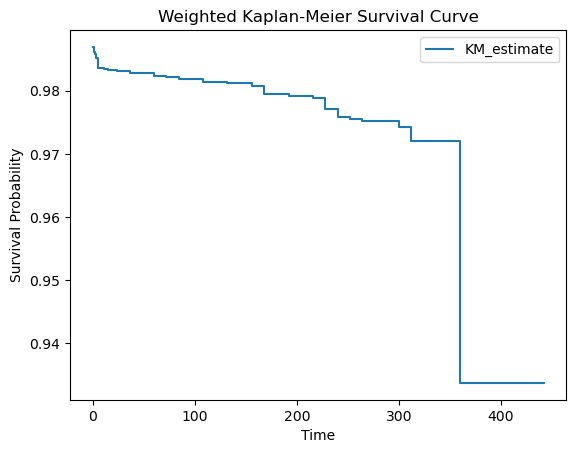

In [44]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="It looks like your weights are not integers"
)

import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_attributes['duration'],
    event_observed=survival_attributes['event'],
    weights=weights   # your non-integer weights
)

kmf.plot(ci_show=False)  # recommended: hide biased CI)

plt.title("Weighted Kaplan-Meier Survival Curve")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()

Interpret as probability of not encountering child mortality.....

$$\begin{array}{|l|l|}
\hline
\textbf{Feature} & \textbf{Interpretation} \\
\hline
\text{Y-Axis Range} & \text{Survival remains very high (above 93\%); child mortality is rare in this sample.} \\
\hline
\text{Small "Steps"} & \text{Each small drop represents one or more deaths at that specific month.} \\
\hline
\text{Large Final Drop} & \text{Likely a small number of "at-risk" individuals left at the end of the study.} \\
\hline
\text{Horizontal Lines} & \text{Periods where no deaths were recorded (survival probability stayed constant).} \\
\hline
\end{array}$$

**Why the big drop at 360 months?**

The "staircase" gets steeper at the end not necessarily because more people are dying, but because the denominator (the number of children still being tracked) has become very small.

In survival analysis, if you only have 5 children left in the study at month 360 and one of them dies, the survival probability will plummet much faster than if one child died at month 10 when you had 8,000 children. This is a common "end-of-study" effect.

**A Quick Check on Your Time Scale**

The X-axis goes up to 440.

If this is in months, then there's tracking children up to roughly 36 years old.

If the research goal is Under-Five Mortality (U5MR), then to filter the data to only look at the first 60 months.

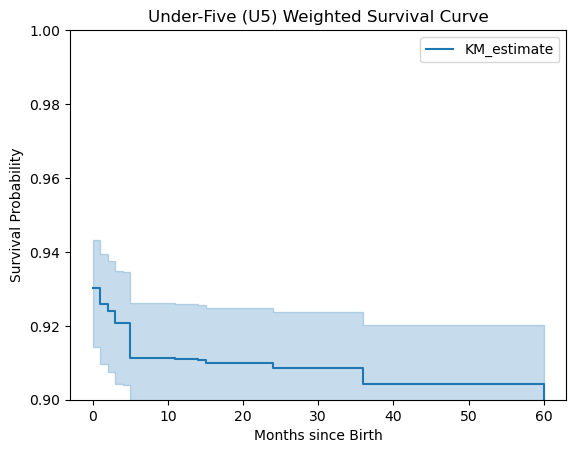

In [45]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="It looks like your weights are not integers"
)

# Filter for children followed up to 5 years (60 months)
df_u5 = survival_attributes[survival_attributes['duration'] <= 60].copy()

# Re-extract the weights for the filtered index
weights_u5 = survival_data.loc[df_u5.index, "wmweight"]


kmf = KaplanMeierFitter()

# Fit the model on the 0-60 month window
kmf.fit(
    durations=df_u5['duration'], 
    event_observed=df_u5['event'], 
    weights=weights_u5
)

# Plot with a focus on the Y-axis to see the detail
ax = kmf.plot_survival_function()
plt.title("Under-Five (U5) Weighted Survival Curve")
plt.xlabel("Months since Birth")
plt.ylabel("Survival Probability")
plt.ylim(0.90, 1.0) # Zooming the Y-axis to see small drops clearly
plt.show()



This "zoomed" plot is much more informative for public health analysis! It clearly shows that the highest risk period is the very beginning of life.

$$\begin{array}{|l|l|}
\hline
\textbf{Observation} & \textbf{Interpretation} \\
\hline
\text{Initial Drop (Months 0-1)} & \text{Neonatal mortality: The curve drops instantly from 1.0 to below 0.94.} \\
\hline
\text{Infancy (Months 1-12)} & \text{The curve continues to step down, reaching roughly 0.91 by the first year.} \\
\hline
\text{Childhood (Months 12-60)} & \text{The slope flattens significantly; survival stabilizes after the first year.} \\
\hline
\text{Confidence Band (Blue Shaded Area)} & \text{Shows the uncertainty (95\% CI). Note it widens as time increases.} \\
\hline
\end{array}$$


**Analysis of the Patterns:**

1. The "Steep Slope" (0–5 Months): Notice how much sharper the drops are in the first few months. This suggests that interventions (like vaccines, breastfeeding support, or neonatal care) would have the biggest impact here.

2. The Survival Plateau: After about month 36 (3 years), the curve is almost flat. This indicates that once a child in this sample reaches age 3, their probability of survival until age 5 is nearly 100%.

3. U5 Survival Rate: According to this graph, approximately 90.5% of children in this population survive to their 5th birthday. Conversely, the Under-Five Mortality Rate is roughly 95 per 1,000 live births.


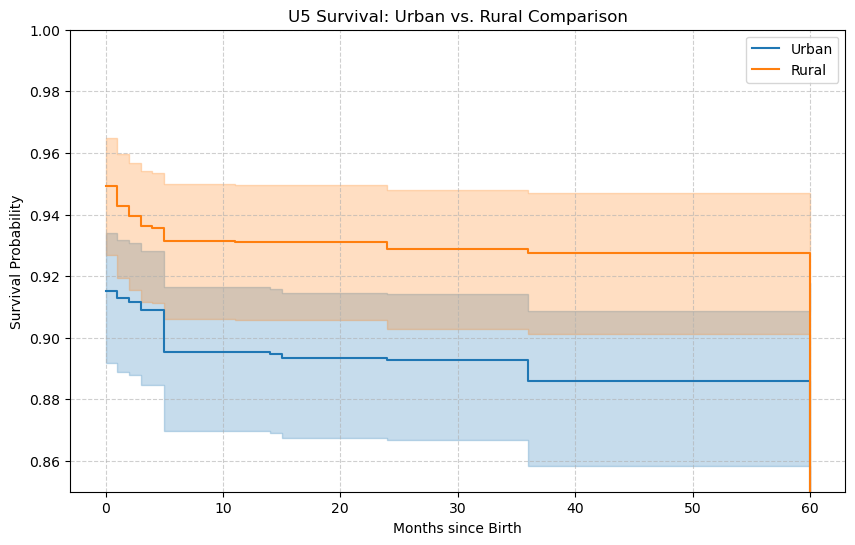

In [46]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# 1. Setup the plot
fig, ax = plt.subplots(figsize=(10, 6))
kmf_urban = KaplanMeierFitter()
kmf_rural = KaplanMeierFitter()

# 2. Filter data by Urban (HH6 == 1) and Rural (HH6 == 2)
urban_mask = (df_u5['HH6'] == 1)
rural_mask = (df_u5['HH6'] == 2)

# 3. Fit and Plot Urban
kmf_urban.fit(df_u5.loc[urban_mask, 'duration'], 
              event_observed=df_u5.loc[urban_mask, 'event'], 
              weights=survival_data.loc[df_u5.loc[urban_mask].index, "wmweight"], 
              label='Urban')
kmf_urban.plot_survival_function(ax=ax)

# 4. Fit and Plot Rural
kmf_rural.fit(df_u5.loc[rural_mask, 'duration'], 
              event_observed=df_u5.loc[rural_mask, 'event'], 
              weights=survival_data.loc[df_u5.loc[rural_mask].index, "wmweight"], 
              label='Rural')
kmf_rural.plot_survival_function(ax=ax)

# 5. Formatting
plt.title("U5 Survival: Urban vs. Rural Comparison")
plt.xlabel("Months since Birth")
plt.ylabel("Survival Probability")
plt.ylim(0.85, 1.0) # Adjust based on your previous plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Cox Model Development**

In [47]:
# Align by index: this ensures rows in survival_data matches rows in survival_attributes and adding 'wmweight.
survival_attributes['wmweight'] = survival_data.loc[survival_attributes.index, 'wmweight']

# Check if any rows are missing weights
missing_weights = survival_attributes['wmweight'].isna().sum()
print(f"Rows missing weights: {missing_weights}")

Rows missing weights: 0


In [48]:
from lifelines import CoxPHFitter

survival_attributes = survival_attributes.drop(columns=['age_group_death', 'age_group_death_int'])

cph = CoxPHFitter()

cph.fit(
    survival_attributes, 
    duration_col='duration', 
    event_col='event', 
    weights_col='wmweight',
    robust=True  
        # Using 'robust=True' handles the non-integer weight issue
        # Add this to fix the biased variance estimate
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 6492.21 total observations, 6358.47 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              weights col = 'wmweight'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6492.21
number of events observed = 133.732
   partial log-likelihood = -1109.05
         time fit was run = 2026-03-22 02:28:56 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
BH2        1.68      5.35      0.32            1.06            2.30                2.88                9.95
BH3       -0.09      0.91      0.23           -0.54            0.37                0.58                1.44
brthord    0.48      1.61      0.19            0.11            0.84                1.12                2.32
birthint  -0.08      0.92      0.09           -0.26            0.09                0.77                1.09
magebrt    0.05      1.05      0.27           -0.48            0.59                0.62                1.80
welevel   -0.19      0.82      0.15           -0.49            0.10                0.61                1.11
wscore    -0.13      0.88      0.10           -0.33            0.07                0.72                1.08
insurance -0.59      0.55      0.26           -1.11           -0.08                0.33                0.92
HH6       -0.47      0.63      0.27           -0.99            0.06                0.37                1.06
HH7        0.01      1.01      0.09           -0.18            0.19                0.84                1.21
ethnicity -0.26      0.77      0.13           -0.52           -0.01                0.60                0.99

           cmp to     z      p  -log2(p)
covariate                               
BH2          0.00  5.30 <0.005     23.00
BH3          0.00 -0.38   0.70      0.51
brthord      0.00  2.57   0.01      6.61
birthint     0.00 -0.94   0.35      1.52
magebrt      0.00  0.19   0.85      0.24
welevel      0.00 -1.27   0.20      2.30
wscore       0.00 -1.23   0.22      2.20
insurance    0.00 -2.26   0.02      5.40
HH6          0.00 -1.75   0.08      3.64
HH7          0.00  0.09   0.93      0.11
ethnicity    0.00 -2.02   0.04      4.51
---
Concordance = 0.62
Partial AIC = 2240.09
log-likelihood ratio test = 60.66 on 11 df
-log2(p) of ll-ratio test = 27.09

### Random Forest

To identify the most influential factors in child survival, to use a Random Forest Classifier to rank feature importance. Since Random Forest is a machine learning algorithm, it is excellent at capturing non-linear relationships (like the complex interaction between wealth, education, and health) that a standard Cox model might miss.

A Random Forest is an ensemble of $B$ independent decision trees (Breiman, 2001), where each tree is grown using a combination of Bagging (Bootstrap Aggregating) and Feature Randomness.

**The Ensemble Model:**

For a regression task, the Random Forest prediction $\hat{f}_{rf}^B(x)$ is the average of the predictions from all individual trees $T_b$:

$$\hat{f}_{rf}^B(x) = \frac{1}{B} \sum_{b=1}^{B} T_b(x, \Theta_b)$$

For classification, the model takes a **majority vote** of the predicted classes.

**The Individual Tree ($T_b$):**

Each tree is trained on a bootstrap sample $Z^*$ of the original training data. During the construction of each tree, at each node split:

A random subset of $m$ features is selected from the total $p$ features (typically $m \approx \sqrt{p}$).

The best split is found only among these $m$ features by minimizing an impurity measure, such as Gini Impurity for classification:

$$G = \sum_{k=1}^{K} \hat{p}_{mk}(1 - \hat{p}_{mk})$$

Or Mean Squared Error (MSE) for regression:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### Random Forest Feature Importance

Random Forest performs feature selection by ranking variables based on how much they contribute to the model's predictive power. The two primary metrics are:

**Mean Decrease in Impurity (MDI / Gini Importance)**

This calculates the total reduction in the loss function (Gini or MSE) brought by a specific feature, averaged over all trees in the forest.

$$VIM_j = \frac{1}{B} \sum_{b=1}^{B} \sum_{t \in T_b : v(s_t)=j} \Delta I(s_t, t)$$

$v(s_t)=j$ means feature $j$ was used for the split at node $t$.

$\Delta I$ is the weighted decrease in impurity from that split.

**Mean Decrease in Accuracy (MDA / Permutation Importance)**

This is often considered more robust. It measures the impact of a feature by randomly shuffling its values in the Out-of-Bag (OOB) samples and observing the drop in model accuracy.

$$Importance(X_j) = \text{Accuracy}_{base} - \text{Accuracy}_{permuted(X_j)}$$

If shuffling a feature's values significantly breaks the model's performance, that feature is deemed highly important.

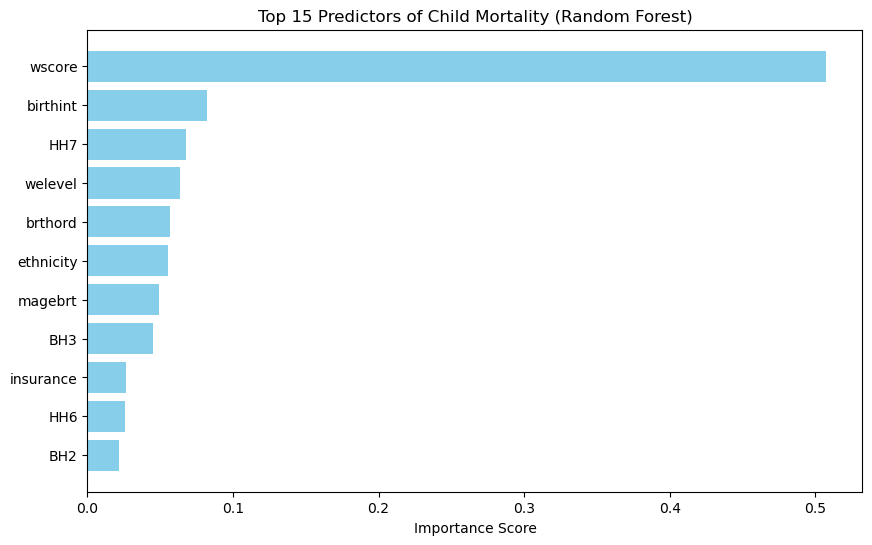

In [49]:
from sklearn.ensemble import RandomForestClassifier

# 1. Prepare Data
# We exclude the target ('event'), the time component ('duration'), and 'wmweight' from predictors
X = survival_attributes.drop(columns=['event', 'duration', 'wmweight'])
y = survival_attributes['event']

# 2. Random Forest Feature Importance
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X, y)

# Get importance scores
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:15], feature_importance_df['Importance'][:15], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 15 Predictors of Child Mortality (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

**Random Forest (prediction power)**

1. wscore dominates (~0.51 importance) → massively more predictive than everything else

2. Then a second tier:

       birthint

       HH7

       welevel

       brthord

       ethnicity

This model is telling you:

    “If I want to predict child mortality, household/wealth-related factors and spacing matter most.”

**Cox Model (statistical significance & direction)**

Significant variables (p < 0.05):

    BH2 → strong positive effect (HR ≈ 5.35)

    brthord → increases risk (HR ≈ 1.61)

    insurance → reduces risk (HR ≈ 0.55)

    ethnicity → reduces risk (HR ≈ 0.77)

Borderline:

    HH6 (p ≈ 0.08)

Not significant:

    wscore (!!)

    birthint

    welevel

    HH7

    magebrt

**Why is wscore:**

🔝 #1 in Random Forest

❌ NOT significant in Cox?

This is a classic case of nonlinear + interaction effects:

**Random Forest:**

    Captures thresholds (e.g., poverty tipping points)

    Captures interactions (wealth × education × household size)

**Cox Proportional Hazards Model:**

    Assumes linear log-hazard relationship

    Misses nonlinear structure unless you explicitly model it

**Translation:**

    Wealth matters a lot, but not in a simple linear way.

**Strongest causal signals (from Cox)**

1. BH2 (HR ~ 5.35)

       → Huge risk increase

       → Likely a critical health/demographic indicator (needs careful interpretation)

2. brthord (birth order)

       → Higher order = higher mortality risk

       → Resource dilution / maternal depletion effect

3. insurance (HR ~ 0.55)

       → Protective effect

       → Access to healthcare matters

4. ethnicity (HR ~ 0.77)

       → Structural/social differences affecting outcomes


**Strong predictors (from Random Forest)**

1. wscore (wealth index)

       → Core socioeconomic driver

2. birthint (birth interval)

       → Spacing between births affects survival

3. welevel (education?)

       → Maternal education proxy

4. HH variables (HH6, HH7)

       → Household composition / crowding


**System likely has:**

Structural drivers (wealth, education, ethnicity)

Biological/demographic drivers (birth order, spacing)

Access factors (insurance)

But:

    The effects are nonlinear and interacting

    Which is why ML picks them up strongly, but Cox underestimates them

### Cox Model with Proportional Hazards Diagnostics (Schoenfeld Residuals)

The main goal is to test the proportional hazards assumption by determining if covariates have time-varying effects (Kuitunen, 2021).

Schoenfeld residuals are used to assess whether the effect of a covariate is constant over time, which is the core assumption in the Cox Proportional Hazards Model.

1. If the model is correct, the hazard ratio $(\beta)$ should not depend on time

2. Schoenfeld residuals help detect time-varying coefficients $\beta(t)$

**Interpretation (Graphical Diagnostics)**

1. For each covariate:

       Plot scaled Schoenfeld residuals vs time

       Add a smooth curve (e.g., LOESS)

2. What you want to see:

       Random scatter around 0

       Smooth curve ≈ flat (horizontal)

3. What it means:

       Residuals ≈ 0 → model assumption holds

       Systematic deviation → time-varying effect

**Signs of Violation (Critical Insight)**

1. Upward or downward trend → monotonic change in hazard ratio

2. Curvature (U-shape, etc.) → non-linear time dependence

3. Step-like pattern → structural break (e.g., policy change, treatment phase)


**Statistical Test (Global + Covariate-Level)**

Typically implemented via Grambsch–Therneau Test

Outputs:

1. Individual p-values (per covariate)

2. Global test (entire model)

Interpretation:

1. p < 0.05 → evidence of violation

2. p ≥ 0.05 → no strong evidence (not proof of validity)

In [50]:
from lifelines.statistics import proportional_hazard_test

**Defining Model Features:**

**Testing Proportional Hazards Assumption Using Schoenfeld Residuals**

In [51]:
# Built-in diagnostic plots

def check_ph_violations(cph, df, alpha=0.05):
    ph_test = proportional_hazard_test(cph, df, time_transform='rank')
    summary = ph_test.summary

    violations = summary[summary['p'] < alpha]

    if len(violations) == 0:
        print("✅ No PH violations detected")
    else:
        print("⚠️ PH violations detected in:")
        print(violations[['test_statistic', 'p']])

    return violations

check_ph_violations(cph, survival_attributes)

⚠️ PH violations detected in:
        test_statistic        p
wscore        6.343616  0.01178


,test_statistic,p,-log2(p)
wscore,6.343616,0.01178,6.407462


**Schoenfeld Residuals:**

1. To plot scaled Schoenfeld residuals vs time

2. Adding smoothing curves

3. Flagging problematic variables

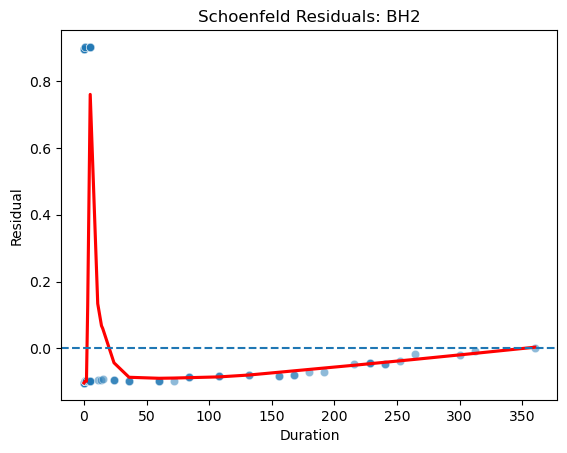

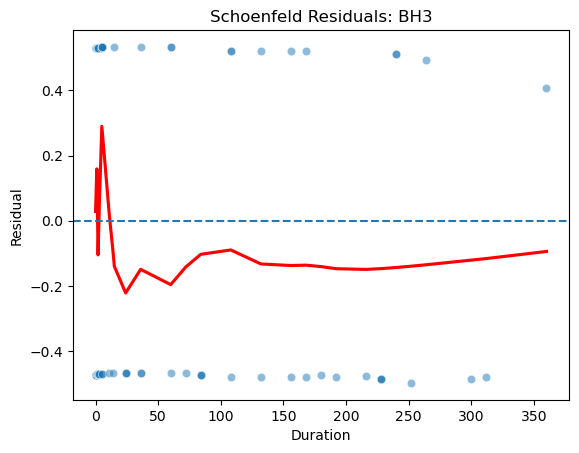

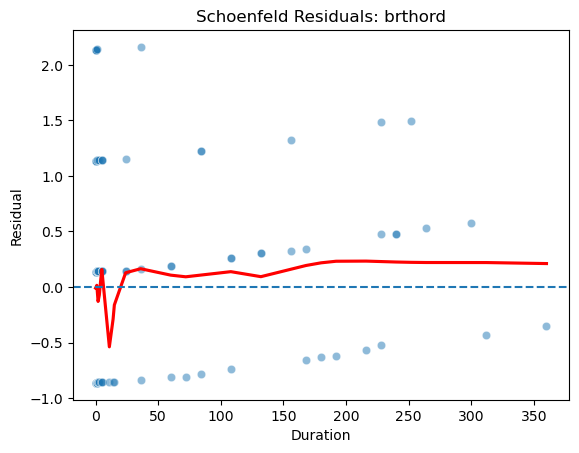

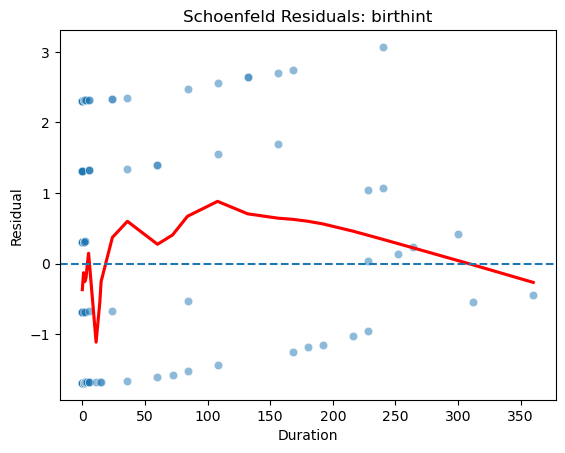

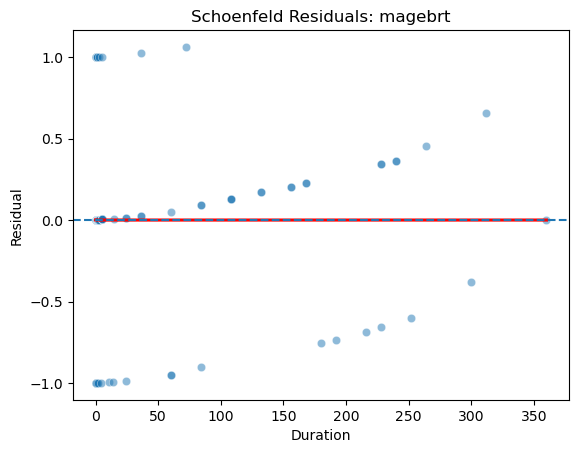

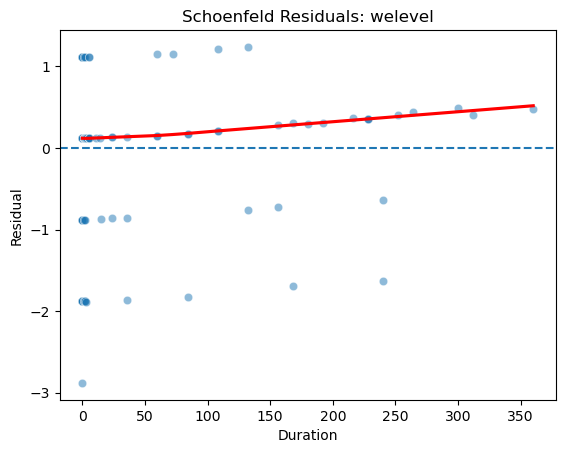

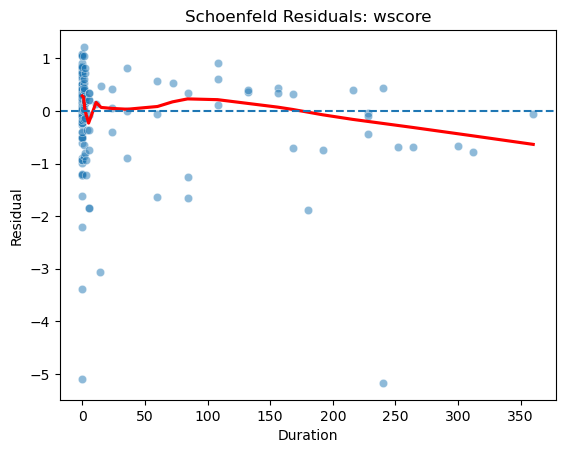

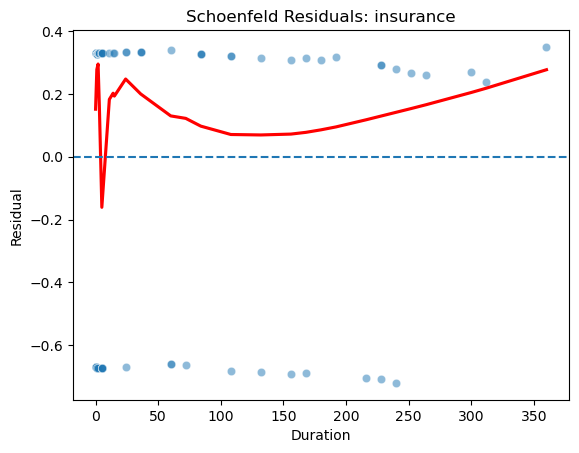

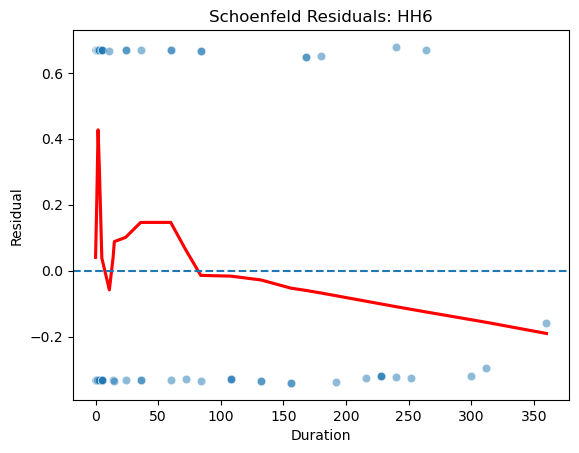

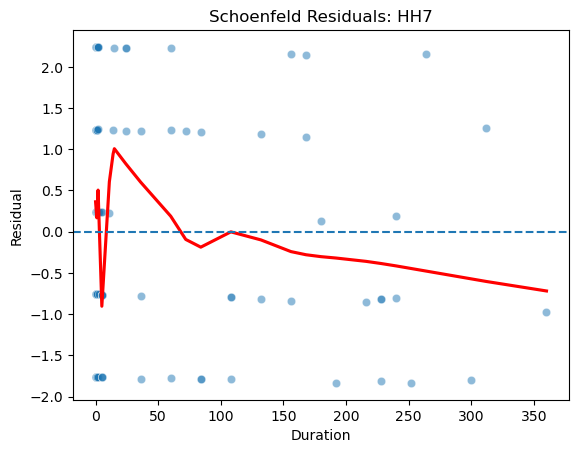

In [52]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Extract residuals
residuals_df =survival_attributes.copy()
residuals = cph.compute_residuals(residuals_df, kind="schoenfeld")

# Merge with time
residuals['duration'] = residuals_df.loc[residuals.index, 'duration']

# Plot for each covariate
for col in residuals.columns[:-2]:  # exclude duration
    plt.figure()
    sns.scatterplot(x=residuals['duration'], y=residuals[col], alpha=0.5)
    sns.regplot(x=residuals['duration'], y=residuals[col],
                scatter=False, lowess=True, color='red')

    plt.axhline(0, linestyle='--')
    plt.title(f"Schoenfeld Residuals: {col}")
    plt.xlabel("Duration")
    plt.ylabel("Residual")
    plt.show()

Comparing the output to the visuals, the latter tends to "convict" many variables as violators. 

### Alternative Models to Cox that can Treat Covariates

#### Accelerated Failure Time (AFT) Model

The AFT Model (Wei, 1992) assumes that covariates act as a multiplier on time, effectively "speeding up" or "slowing down" the "aging" process.

**Weibull (AFT) Model**

In a Weibull AFT framework, the log of the survival time $T$ is modelled linearly:

$$\ln(T) = \mu + \mathbf{\beta X} + \sigma W$$

$\mathbf{\beta X}$: The linear predictor of covariates.

$\sigma$: The scale parameter.

$W$: An error term following the Extreme Value distribution.

The Extreme Value Distribution (EVD), specifically the Type I (Gumbel) distribution, is the mathematical foundation for the error term $W$ in the Weibull AFT model you mentioned earlier. While a Normal distribution describes the "average" behaviour of a system, EVDs describe the behavior of the maxima or minima of a large number of independent samples.

1. The Gumbel (Type I) Distribution:

In the context of survival analysis and AFT models, to use the standard Gumbel distribution for the error term. Its Probability Density Function (PDF) is defined as:

$$f(w) = e^{w - e^w}$$

And its Cumulative Distribution Function (CDF) is:

$$F(w) = 1 - e^{-e^w}$$

2. Relationship to the Weibull Model

The reason to use the Gumbel distribution in the Weibull AFT model is due to a logarithmic transformation. If a random variable $T$ (time) follows a Weibull distribution, then $W = \ln(T)$ follows a Gumbel distribution.

Symmetry: Unlike the Normal distribution, the EVD is asymmetric (skewed). This makes it ideal for survival data, where "failure" events often cluster or have long "tails" (extreme outliers).

Location and Scale: In the AFT equation $\ln(T) = \mu + \sigma W$, the $\mu$ shifts the location of the distribution, while $\sigma$ stretches or compresses it.

Because the Weibull distribution is unique in being both a Proportional Hazards (PH) and an AFT model, the acceleration factor $AF$ is related to the coefficients by $AF = \exp(\mathbf{\beta X})$.

**Log-Normal AFT Model**

The Log-Normal AFT model follows the same linear structure for the logarithm of time but assumes a different distribution for the error term:

$$\ln(T) = \mu + \mathbf{\beta X} + \sigma W$$

$W$: In this case, $W$ follows a Standard Normal distribution $N(0, 1)$.

Survival Function: The probability of surviving beyond time $t$ is given by:

$$S(t | \mathbf{X}) = 1 - \Phi\left( \frac{\ln(t) - (\mu + \mathbf{\beta X})}{\sigma} \right)$$

where $\Phi$ is the cumulative distribution function of the standard normal distribution.

Unlike the Weibull, the Log-Normal model does not have a proportional hazards representation; it is strictly an AFT model where the hazard rate can be non-monotonic (e.g., increasing then decreasing).

| Feature                    | Weibull AFT | Log-Normal AFT |
| -------------------------- | ----------- | -------------- |
| Distribution assumption    | Weibull     | Log-normal     |
| Handles non-PH             | ✅           | ✅              |
| Interpretability           | ⭐⭐⭐⭐        | ⭐⭐⭐⭐           |
| Nonlinear effects          | ❌           | ❌              |
| Interactions               | ❌           | ❌              |
| Extrapolation              | ✅           | ✅              |
| Robust to misspecification | ❌           | ❌              |
| Policy insight             | ⭐⭐⭐⭐        | ⭐⭐⭐⭐           |


Now, checking for durations with 0 because such isn't compatible with models like Weibull AFT, etc.:

In [53]:
duration_check = survival_attributes[survival_attributes["duration"] <= 0]
print(duration_check)

      duration  event  BH2  BH3  brthord  birthint  magebrt  welevel  \
129        0.0      0  1.0  2.0      1.0       0.0      1.0      3.0   
136        0.0      1  1.0  1.0      2.0       4.0      2.0      3.0   
288        0.0      1  1.0  2.0      2.0       4.0      2.0      0.0   
314        0.0      1  1.0  1.0      1.0       0.0      1.0      3.0   
437        0.0      1  1.0  1.0      1.0       0.0      2.0      3.0   
...        ...    ...  ...  ...      ...       ...      ...      ...   
7946       0.0      1  1.0  2.0      4.0       4.0      3.0      2.0   
8009       0.0      1  1.0  2.0      1.0       0.0      1.0      3.0   
8010       0.0      1  1.0  1.0      2.0       2.0      1.0      3.0   
8060       0.0      1  1.0  2.0      3.0       4.0      2.0      1.0   
8201       0.0      1  2.0  2.0      2.0       3.0      2.0      3.0   

        wscore  insurance  HH6  HH7  ethnicity  wmweight  
129   0.264154        2.0  1.0  1.0        1.0  1.888704  
136   0.600564   

Resolving such issue with small epsilon to zero adjustment that will Keeps all observations:

In [54]:
adj_df = survival_attributes.copy()

# Adding a small epsilon to zero durations:
adj_df["duration"] = adj_df["duration"].clip(lower=1e-5)

weights = survival_data.loc[adj_df.index, "wmweight"]

Developing the Weibull AFT model:

In [55]:
from lifelines import WeibullAFTFitter

weibull_aft = WeibullAFTFitter()
weibull_aft.fit(adj_df, duration_col="duration", event_col="event",
                weights_col="wmweight", robust=True)

weibull_aft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 6492.21 total observations, 6358.47 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              weights col = 'wmweight'
          robust variance = True
   number of observations = 6492.21
number of events observed = 133.732
           log-likelihood = -252.31
         time fit was run = 2026-03-22 02:29:10 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                   
lambda_ BH2       -18.14      0.00      4.63          -27.21           -9.07                0.00                0.00
        BH3         0.86      2.36      2.21           -3.47            5.19                0.03              179.87
        HH6         5.18    178.42      2.95           -0.60           10.97                0.55            58157.34
        HH7        -0.02      0.98      1.07           -2.12            2.08                0.12                7.98
        birthint    1.03      2.79      0.92           -0.78            2.84                0.46               17.06
        brthord    -5.30      0.00      2.44          -10.09           -0.51                0.00                0.60
        ethnicity   2.90     18.10      1.34            0.26            5.53                1.30              251.78
        insurance   6.63    757.32      2.63            1.47           11.79                4.36            1.32e+05
        magebrt     1.34      3.82      2.81           -4.16            6.85                0.02              939.37
        welevel     2.41     11.17      1.30           -0.13            4.96                0.88              141.96
        wscore      1.17      3.22      1.06           -0.90            3.24                0.41               25.52
        Intercept  38.91  7.91e+16     10.20           18.93           58.89            1.66e+08            3.77e+25
rho_    Intercept  -2.39      0.09      0.06           -2.51           -2.26                0.08                0.10

                   cmp to      z      p  -log2(p)
param   covariate                                
lambda_ BH2          0.00  -3.92 <0.005     13.47
        BH3          0.00   0.39   0.70      0.52
        HH6          0.00   1.76   0.08      3.66
        HH7          0.00  -0.02   0.98      0.02
        birthint     0.00   1.11   0.27      1.91
        brthord      0.00  -2.17   0.03      5.06
        ethnicity    0.00   2.16   0.03      5.01
        insurance    0.00   2.52   0.01      6.41
        magebrt      0.00   0.48   0.63      0.66
        welevel      0.00   1.86   0.06      3.99
        wscore       0.00   1.11   0.27      1.89
        Intercept    0.00   3.82 <0.005     12.85
rho_    Intercept    0.00 -37.49 <0.005   1019.45
---
Concordance = 0.62
AIC = 530.61
log-likelihood ratio test = 59.63 on 11 df
-log2(p) of ll-ratio test = 26.46

Developing the Log-Normal AFT model:

In [56]:
from lifelines import LogNormalAFTFitter

lognormal_aft = LogNormalAFTFitter()
lognormal_aft.fit(adj_df, duration_col="duration", event_col="event",
                 weights_col="wmweight", robust=True)

lognormal_aft.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 6492.21 total observations, 6358.47 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              weights col = 'wmweight'
          robust variance = True
   number of observations = 6492.21
number of events observed = 133.732
           log-likelihood = -250.55
         time fit was run = 2026-03-22 02:30:18 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                   
mu_    BH2       -20.15      0.00      5.53          -30.99           -9.31                0.00                0.00
       BH3         2.14      8.47      2.25           -2.28            6.56                0.10              703.45
       HH6         5.08    161.30      2.99           -0.78           10.95                0.46            56746.79
       HH7        -0.14      0.87      1.11           -2.32            2.04                0.10                7.70
       birthint    1.25      3.49      1.01           -0.72            3.22                0.49               25.09
       brthord    -5.40      0.00      2.61          -10.51           -0.28                0.00                0.76
       ethnicity   2.54     12.68      1.32           -0.05            5.13                0.95              168.25
       insurance   6.33    560.16      2.73            0.98           11.68                2.65            1.18e+05
       magebrt     0.39      1.48      2.83           -5.15            5.93                0.01              377.95
       welevel     2.13      8.38      1.35           -0.53            4.78                0.59              118.88
       wscore      1.14      3.13      1.14           -1.10            3.38                0.33               29.40
       Intercept  56.78  4.56e+24     11.56           34.12           79.44            6.60e+14            3.15e+34
sigma_ Intercept   3.31     27.49      0.06            3.20            3.43               24.55               30.78

                  cmp to     z      p  -log2(p)
param  covariate                               
mu_    BH2          0.00 -3.64 <0.005     11.85
       BH3          0.00  0.95   0.34      1.54
       HH6          0.00  1.70   0.09      3.49
       HH7          0.00 -0.12   0.90      0.15
       birthint     0.00  1.24   0.21      2.22
       brthord      0.00 -2.07   0.04      4.69
       ethnicity    0.00  1.93   0.05      4.20
       insurance    0.00  2.32   0.02      5.61
       magebrt      0.00  0.14   0.89      0.17
       welevel      0.00  1.57   0.12      3.11
       wscore       0.00  1.00   0.32      1.65
       Intercept    0.00  4.91 <0.005     20.08
sigma_ Intercept    0.00 57.36 <0.005       inf
---
Concordance = 0.62
AIC = 527.10
log-likelihood ratio test = 54.25 on 11 df
-log2(p) of ll-ratio test = 23.17

The AFTs appear to be better fits, however, they are still a bit in contradiction with features such as 'wscore',  'welevel', 'HH7' and 'insurance'.

## Learning Poverty

Learning Poverty (World Bank, 2021)—defined as the inability of a child to read and comprehend a simple text by age 10—is a critical barrier to human capital development. Conventional measures often rely on school-based assessments, which exclude the most vulnerable: out-of-school children. This framework utilizes UNICEF MICS6 data (**now MICS7 here**), specifically the Foundational Learning Skills (FLS) module, to develop supervised machine learning models (e.g., XGBoost, Random Forest) that predict proficiency at the individual child level. By integrating household socioeconomic indicators, parental education, and environmental factors, the model identifies "at-risk" clusters and provides granular, sub-national insights to guide targeted policy interventions in low- and middle-income countries.

**The Core Metric: Learning Poverty (LP)**

The indicator is a composite measure that accounts for both the quality of education and the lack of access to it. It is formally expressed as:

$$LP = [LD \times (1 - SD)] + [1 \times SD]$$

1. $LD$ (Learning Deprivation): The share of children in school who are below minimum reading proficiency.

2. $SD$ (Schooling Deprivation): The share of primary-aged children who are out of school (assumed to be non-proficient).

**The Advantage with MICS Data**

While many education datasets (like PIRLS or PISA) are school-based, MICS is a household survey. This allows for:

1. Inclusion of Out-of-School Children: Captures the $SD$ component of the formula.

2. Foundational Learning Module: Specifically tests children aged 7–14 on basic literacy and numeracy, providing the "ground truth" labels for $LD$.

3. Multidimensional Context: Links learning outcomes to household wealth, child labor, disability status, and home language.

Data of interest — the 5–17 Child dataset (fs.sav)

It typically contains:

1. Foundational learning skills (reading/math modules)

2. School attendance

3. Child demographics

4. Sometimes ICT and learning environment indicators


In the context of Education Economics and the Learning Poverty (LP) metric, this formula is a weighted aggregation used by organizations like the World Bank to account for both the quality of schooling and the lack of access to it. 

The $LP$ formula effectively partitions the child population into two groups to determine the total share of children who cannot read and understand a simple text by age 10.

**Understanding the Range and Logic**

Since both $LD$ and $SD$ are defined as shares (proportions), their individual ranges are $[0, 1]$ (or $0\%$ to $100\%$). Consequently, the range of $LP$ is also $[0, 1]$.

How the components interact to define that range:

1. The Schooling Component $[1 \times SD]$: This assumes that $100\%$ of children out of school are "Learning Deprived." Therefore, $SD$ contributes its full value to the total Poverty score.

2. The Learning Component $[LD \times (1 - SD)]$: This applies the "Learning Deprivation" rate only to the portion of children who are actually in school $(1 - SD)$.

**Mathematical Properties**

This formula is a convex combination. It ensures that:

1. $LP$ is always $\geq\,SD$: You cannot have less Learning Poverty than your out-of-school rate.

2. $LP$ is always $\geq\,LD$: (Assuming $LD\leq\,1$). The total deprivation is always higher than the deprivation of just those in school, because it adds the "assumed non-proficient" out-of-school children.

**Scenario Analysis**

| Scenario | Variables | Result (LP) | Interpretation |
|----------|-----------|--------------|----------------|
| Perfect Education | LD = 0, SD = 0 | 0 | No one is out of school; everyone in school is proficient. |
| Total Crisis | LD = 1, SD = 0 | 1 | Everyone is in school, but no one reaches proficiency. |
| No Schooling | LD = n, SD = 1 | 1| Even if the schools are great, no one attends them. |

The *Total Crisis* and *No Schooling* outcomes in terms of economics can be labelled as externalities or market failure. Namely, there's no efficient or sufficient use of the public good/service in regard to cost and benefit. There's also the possible outcome of students in the future not qualifying for occupations or positions in society that lead to socioeconomic benefit/ascension. 

To now assimilate data for learning poverty development:

In [57]:
df_fs, meta_fs = pyreadstat.read_sav("fs.sav") # children 5 to 17 years of age

Inspecting the dataset:

In [58]:
df_fs.info() # variable names

fs_codebook = pd.DataFrame({
    "variable": meta_fs.column_names,
    "label": meta_fs.column_labels
})

fs_codebook

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3251 entries, 0 to 3250
Columns: 331 entries, HH1 to psu
dtypes: float64(286), object(45)
memory usage: 8.2+ MB


,variable,label
0,HH1,Cluster number
1,HH2,Household number
2,LN,Line number
3,FS1,Cluster number
4,FS2,Household number
...,...,...
326,wscorer,Rural wealth score
327,windex5r,Rural wealth index quintile
328,windex10r,Rural wealth index decile
329,stratum,Sample strata


In [59]:
meta_fs.variable_value_labels # values for variables

{'FS9': {1.0: 'YES, INTERVIEWED ALREADY', 2.0: 'NO, FIRST INTERVIEW'},
 'FS10': {1.0: 'YES', 2.0: 'NO / NOT ASKED'},
 'FS15C': {1.0: 'YES', 2.0: 'NO'},
 'FS15D': {1.0: 'YES', 2.0: 'NO PHONE'},
 'FS17': {1.0: 'COMPLETED',
  2.0: 'NOT AT HOME',
  3.0: 'REFUSED',
  4.0: 'PARTLY COMPLETED',
  5.0: 'INCAPACITATED (SPECIFY)',
  6.0: 'NO ADULT CONSENT FOR MOTHER / CARETAKER AGE 15-17',
  96.0: 'OTHER (SPECIFY)'},
 'FS12': {1.0: 'ENGLISH',
  2.0: 'SPANISH',
  3.0: 'MANDARIN',
  6.0: 'OTHER LANGUAGE (MODIFY)',
  9.0: 'NO RESPONSE'},
 'FS13': {1.0: 'ENGLISH', 2.0: 'SPANISH'},
 'FS14': {1.0: 'ENGLISH',
  2.0: 'SPANISH',
  3.0: 'MANDARIN',
  6.0: 'OTHER LANGUAGE (MODIFY)',
  9.0: 'NO RESPONSE'},
 'FS15': {1.0: 'YES, THE ENTIRE QUESTIONNAIRE',
  2.0: 'YES, PARTS OF THE QUESTIONNAIRE',
  3.0: 'NO, NOT USED',
  9.0: 'NO RESPONSE'},
 'FSFIN': {1.0: 'REVIEW QUESTIONNAIRE',
  2.0: 'ADD NOTES',
  3.0: 'SAVE QUESTIONNAIRE AND FINISH'},
 'CB2M': {1.0: 'JANUARY',
  2.0: 'FEBRUARY',
  3.0: 'MARCH',
  4.0: 'A

Inspecting the variable types:

In [60]:
# General overview of variable types
df_fs.dtypes

HH1          float64
HH2          float64
LN           float64
FS1          float64
FS2          float64
              ...   
wscorer      float64
windex5r     float64
windex10r    float64
stratum      float64
psu          float64
Length: 331, dtype: object

In [61]:
# Observation of object columns
obj_cols = df_fs.select_dtypes(include=['object']).columns
print(obj_cols)
len(obj_cols)

Index(['CB12B', 'CB12D', 'CB12X', 'CB12NR', 'FL4A', 'FL4B', 'FL4C', 'FL16',
       'FL18', 'FS15IA$1', 'FS15IA$2', 'FS15IA$3', 'FS15IA$4', 'FS15IB$1',
       'FS15IB$2', 'FS15IB$3', 'FS15IB$4', 'FS15IC$1', 'FS15IC$2', 'FS15IC$3',
       'FS15IC$4', 'FS15ID$1', 'FS15ID$2', 'FS15ID$3', 'FS15ID$4', 'FS15IE$1',
       'FS15IE$2', 'FS15IE$3', 'FS15IE$4', 'FS15IF$1', 'FS15IF$2', 'FS15IF$3',
       'FS15IF$4', 'FS15IG$1', 'FS15IG$2', 'FS15IG$3', 'FS15IG$4', 'FS15IH$1',
       'FS15IH$2', 'FS15IH$3', 'FS15IH$4', 'FS15IX$1', 'FS15IX$2', 'FS15IX$3',
       'FS15IX$4'],
      dtype='object')


45

In [62]:
# Observation of float columns
float_cols = df_fs.select_dtypes(include=['float']).columns
print(float_cols)
len(float_cols)

Index(['HH1', 'HH2', 'LN', 'FS1', 'FS2', 'FS3', 'FSINT', 'FS4', 'FS5', 'FS6',
       ...
       'windex5', 'windex10', 'wscoreu', 'windex5u', 'windex10u', 'wscorer',
       'windex5r', 'windex10r', 'stratum', 'psu'],
      dtype='object', length=286)


286

### Learning Poverty Model Recollection

Concerning the $LD$ formula introduced earlier, with respect to the given data, a direct approach with such may not be as informative as models containing critical attributes that reveal structure or conditions for learning poverty outcome. The $LD$ formula only stratifies individuals to grasp inequality or dispersion in learning in a population. On ther other hand, models that rely on statistical significance for features (predictors) aim to capture reasons for outcome. Statistical models however are prone to errors or inadequacy due to the following possible reasons (just to name a few):

1. Parametric construction with assumptions that may not be general;

2. Nonlinear characteristics/behaviour in data (features);

3. Interacting behaviour among the features;

4. Underlying/hidden temporal behaviour of the attributes (target and/or features);

5. Volatility due to systematic or environmental hazards (both $LD$ model and statisical models can be inhibited overall).

6. Poor quality in data, or inadequate data for analysis;

7. Biases in operation of data acquasition (both $LD$ model and statisical models can be inhibited overall).

**NOTE:** non-parameteric models generally peform better with decent amount of data. **However**, interpretability for socioeconomic and policy is highly elusive. Nevertheless, statistical models are often the most practical because deterministic or analytical models require extremely sound beliefs or axioms; such are what statistical models circumvent reasonably well. 

### Learning Poverty Model Development

There will be two complimentary models:

| Model   | Target Type               | Purpose                         |
| ------- | ------------------------- | ------------------------------- |
| Model 1 | Binary (Learning Poverty) | Standard policy metric          |
| Model 2 | Ordinal (Learning Levels) | More nuanced skill distribution |

#### Model 1 - Binary Learning Poverty (Main Model)

Target Definition (Exact) Using:

1. FL21A $\rightarrow$ reading accuracy threshold

2. FL21B $\rightarrow$ comprehension

In logistic regression (or logit model), the objective is to map a linear combination of independent variables to a probability $p$ that falls strictly between $0$ and $1$ (Sperandei, 2014).

The Linear Predictor - starting with a standard linear equation, often called the log-odds or logit:

$$\eta = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots + \beta_nx_n$$

where log-odds transforms probability range $[0, 1]$ to $[-\infty, +\infty]$.

The Link Function (Logit) - connects the probability $p$ to the linear predictor. It is defined as the natural logarithm of the odds:

$$\text{logit}(p) = \ln\left(\frac{p}{1 - p}\right) = \eta$$

where $\frac{p}{1-p}$ is the ratio of "success" to failure".

The Logistic Function (Sigmoid) - to solve for $p$, to take the inverse of the logit function. This gives the Standard Logistic Function, which creates the characteristic S-shaped curve:

$$p = \frac{1}{1 + e^{-\eta}}$$

where $\sigma(\eta)$ compresses any real number back into a valid probability $[0, 1]$.

**Statistical Estimation**

Unlike Linear Regression, which uses Ordinary Least Squares (OLS), the parameters ($\beta$) in a logit model are typically estimated using Maximum Likelihood Estimation (MLE). This method finds the coefficients that make the observed data most probable.

In [63]:
import pandas as pd

# Set to None to show ALL rows and ALL columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

**Display of all attributes:**

In [64]:
fs_codebook

,variable,label
0,HH1,Cluster number
1,HH2,Household number
2,LN,Line number
3,FS1,Cluster number
4,FS2,Household number
5,FS3,Child's line number
6,FSINT,Interviewer number
7,FS4,Mother / Caretaker's line number
8,FS5,Interviewer number
9,FS6,Supervisor number


**Filtering to Only Possess Completed Questioning**

Attribute 'FS17' : result of interview for child age 5-17 years

1. COMPLETED	01

2. NOT AT HOME	02

3. REFUSED	03

4. PARTLY COMPLETED	04

5. INCAPACITATED
	(specify)	05
6. NO ADULT CONSENT FOR MOTHER/
	CAREGIVER AGE 15-17	06

7. OTHER (specify)	96

Concerned with only those who have completed the survey:

In [65]:
# Filter for only completed interviews in the 5-17 module
df_fs = df_fs[df_fs['FS17'] == 1].copy()

**Accounting for official missing data code designation besides "blanks" in data:**

In [66]:
# Expanded MICS/DHS missing and special codes
# 6: Other, 7: Inconsistent, 8: Don't Know, 9: Missing/Refused
missing_codes = [
    6, 7, 8, 9,          # 1-digit fields
    96, 97, 98, 99,      # 2-digit fields
    996, 997, 998, 999   # 3-digit fields
]

df_fs = df_fs.replace(missing_codes, np.nan)

Determining the percentage of missing data for each column:

In [67]:
import pandas as pd

# Calculate missing count and missing percentages
missing_count = df_fs.isnull().sum()
missing_percent = 100 * df_fs.isnull().sum() / len(df_fs)

# Combine into a table
missing_table = pd.concat([missing_count, missing_percent], axis=1)
missing_table.columns = ['Missing Values', '% of Total Values']

# Filter for only missing columns and sort descending
missing_table = missing_table[missing_table['Missing Values'] > 0].sort_values('Missing Values', ascending=False)

print(missing_table)

             Missing Values  % of Total Values
FS15G$4                3131         100.000000
FL18B                  3131         100.000000
FS12                   3131         100.000000
FS15H$3                3131         100.000000
FS15H$4                3131         100.000000
FS15G$3                3131         100.000000
FS15J$4                3131         100.000000
FS15J$3                3131         100.000000
CL10                   3126          99.840307
FS15H$2                3121          99.680613
FCF11                  3121          99.680613
FS15J$2                3121          99.680613
FS15G$2                3121          99.680613
FCF13                  3119          99.616736
FCF10                  3115          99.488981
FCF12                  3114          99.457042
FL26B                  3100          99.009901
FS15J$1                2999          95.784095
FS15H$1                2999          95.784095
FS15G$1                2999          95.784095
FS15D        

**Target Development:**

Now, for the target construction. Recall Target Definition (Exact) Using:

1. FL21A $\rightarrow$ reading accuracy threshold

2. FL21B $\rightarrow$ comprehension

To now implement a disjunctive binary classification (an OR logic gate) to identify individuals who meet the criteria for "Learning Poverty" based on two distinct diagnostic dimensions: technical decoding and cognitive understanding.

**Analytical Explanation**

The purpose of this code is to construct a stringent proficiency threshold. By moving from a single comprehension check to 11 distinct items, you are significantly increasing the "sensitivity" of the poverty marker.

**Multidimensional Failure Logic**
The variable poor_reading_comprehension now treats "proficiency" as a fragile state. Because we use the Boolean OR logic across all 12 variables (FL21A + the 11 comprehension items), the child is flagged if they fail any single component.

Mathematical Structure: $Y = 1$ if $(\text{FL21A} = 1) \cup (\text{FL21BA} > 1) \cup \dots \cup (\text{FL23F} > 1)$.

Result: A child must score a 2 in first test, and 1 on all latter eleven tests to be considered "Not Poor."

In [68]:
import pandas as pd

# List of columns representing comprehension tasks
comp_cols = [
    'FL21BA', 'FL21BB', 'FL21BC', 'FL21BE', 'FL21BF', 
    'FL23A', 'FL23B', 'FL23C', 'FL23D', 'FL23E', 'FL23F'
]

# 1. Identify failure in basic reading (FL21A), being a score of 1 
poor_reading = (df_fs["FL21A"] == 1)

# 2. Identify failure in ANY of the comprehension tasks (2 or 3)
# We use .any(axis=1) to flag a row if at least one column is > 1
poor_comprehension = (df_fs[comp_cols] > 1).any(axis=1)

# 3. Final Target: Poor Reading OR Poor Comprehension
df_fs["learning_poverty_bin"] = (poor_reading | poor_comprehension).astype(int)

# Optional: Verify the distribution
print(df_fs["learning_poverty_bin"].value_counts())

learning_poverty_bin
0    2714
1     417
Name: count, dtype: int64


**Feaatures of Interest:**

Age of child - due count of missing data in CB3, to get the age in years, subtract the child's birth date (FSDOB) from the date of the interview (FWDOI - Fieldwork Date of Interview) with consideration of the CMC standard:

$$\text{Age in Years} = \left\lfloor \frac{\text{Median(FWDOI)} - \text{FSDOB}}{12} \right\rfloor$$

Analytically, taking the median of FWDOI is a sound statistical safeguard when there's a significant amount of missing data in the primary Age variable.

In MICS datasets, FWDOI (Fieldwork Date of Interview) is recorded in Century Month Code (CMC). Since surveys are typically conducted over a relatively short window (3–6 months), using the median CMC as a "point-in-time" reference for the entire sample introduces very little bias compared to the benefit of recovering 1,218 missing age values.

Sex: HL4

Area: HH6

Region: HH7

Ever attended school or early childhood programme: CB4

Child's education: fselevel

Urban wealth index quintile: windex5u

Rural wealth index quintile: windex5r

Mother's education: melevel

In the last 12 months - received a student or student report card: PR10

In the last 12 months school closed due to - natural disasters: PR12A

Compared with children of the same age, child has difficulty learning things: FCF19

Hours worked in past week: CL3

Activities required carrying heavy loads: CL4

Activities required working with dangerous tools or heavy machinery: CL5

Description of work: exposed to extreme temperatures or humidity: CL6B

Language of the Interview: FS13

Native language of the Respondent: FS14

Children 5-17's sample weight: fsweight

**Why MICS Weights Exist:**

MICS is a complex survey, meaning:

1. households are sampled with unequal probabilities

2. clusters/regions are over- or under-sampled

3. non-response adjustments are applied

So weights correct for:

1. representativeness (population inference)

2. selection bias from survey design

**Feature Engineering with Cleaner Feature Names:**

In [69]:
# Columns to drop
cols_to_drop = ["fshweight", "wscore", "wscoreu", "wscorer"]
df_fs = df_fs.drop(columns=cols_to_drop, errors="ignore")


# CORE VARIABLES

# This will give you the actual average interview month in CMC terms
actual_median_cmc = df_fs['FSDOI'].median()

# Calculate age based on the 2022 interview timing
# Use "Int64" (capital I) to allow for missing values (NaN)
df_fs['Age_2022'] = ((actual_median_cmc - df_fs['FSDOB']) / 12).apply(np.floor).astype("Int64")

df_fs["sex"] = df_fs["HL4"]

df_fs["ever_attended"] = df_fs["CB4"]
df_fs["education_level"] = df_fs["fselevel"]

df_fs["urban"] = df_fs["HH6"] 
df_fs["region"] = df_fs["HH7"]

df_fs["mother_education"] = df_fs["melevel"]

df_fs["report_card"] = df_fs["PR10"]
df_fs["school_disruption"] = df_fs["PR12A"]

df_fs["difficulty_learning"] = df_fs["FCF19"] 

df_fs["hours_worked"] = df_fs["CL3"].fillna(0)

df_fs["hazardous_work"] = (
    (df_fs["CL4"] == 1) |
    (df_fs["CL5"] == 1) |
    (df_fs["CL6B"] == 1)
).astype(int) # All conditions must be satisfied to recognise hazardous_work

# Create the binary match feature
df_fs['lang_match'] = (df_fs['FL7'] == df_fs['FL9']).astype(int)

df_fs["language_mismatch"] = (df_fs["FS14"] != df_fs["FS13"]).astype(int)

# Wealth (combine urban/rural)
df_fs["wealth_quintile"] = df_fs["windex5u"].fillna(df_fs["windex5r"]) 
       # to make certain that no one is left out despite whatever status concerning valid responses

**CATEGORISATION FOR THE df_fs ATTRIBUTES:**

1. **Demographic Factors**

       Basic biological and geographic descriptors used to "level the playing field" in your model.

       Age_2022: Vital for normalization (older children are expected to know more).

       sex: To control for gender-based educational disparities.

       urban: Geographic setting (Urban vs. Rural).

       region: Administrative or geographical location.

   

3. **Socioeconomic Status (SES)**

       wealth_quintile: The primary indicator of household assets and financial stability.

       mother_education: A critical "proxy" for the home learning environment and early childhood stimulation.

4. **School System & Educational History (concerning child's formal interaction with the education sector)**

       ever_attended: Indicates baseline access to the school system.

       education_level: The current "grade" or stage of schooling.

       school_disruption: Captures external shocks to the system (strikes, weather, etc.).

5. **Economic Activity & Labor (factors that "compete" with school for the child's time and energy)**

       hours_worked: Quantifies "time poverty"—how much learning time is lost to labor.

       hazardous_work: An indicator of extreme economic vulnerability and physical/mental stress.

6. **Cultural & Linguistic (Instructional Fit) - attributes that define the "match" between the child's identity and the school's requirements**

       lang_match / language_mismatch: These are your "bridge" features. They identify if the child is culturally/linguistically integrated into the classroom or marginalized by the medium of instruction.

7. **Developmental & Performance Metrics**

       These are your "Outcome" or "Status" variables. NOTE: using these as predictors for "poor learning" can cause circular logic (data leakage).

       difficulty_learning: A subjective/qualitative assessment of the child’s cognitive function.

8. **Survey Metadata (Weights)**

        fsweight: This is not a "feature" in the traditional sense; it is a Sampling Weight. NOTE: will not be directly a feature, Applied as models' sample_weight parameter to ensure your results are representative of the actual population.

Age observation:

In [70]:
df_fs['Age_2022'].describe()

count      3131.0
mean     10.32801
std      3.816566
min           4.0
25%           7.0
50%          10.0
75%          14.0
max          18.0
Name: Age_2022, dtype: Float64

**Applying the 7-14 Age Restriction:**

Applying the 7–14 age restriction is not just a blind data cleaning step; it is a requirement for functional and statistical validity when using UNICEF MICS data to measure learning outcomes.

Analytically, including children outside this range would introduce "noise" that would invalidate the Logit model's results. Why this specific window is mandatory:

The "Universe" of the Survey Instrument --

1. The Foundational Learning (FL) module in MICS, which contains the variables you are using (FL21, FL23), is strictly administered only to one randomly selected child aged 7–14 per household.

       If Age < 7: These children were never asked these questions. Their rows in your dataset will contain NaN or "System Missing" values. Including them would force your model to drop those rows anyway, or worse, treat them as "0" (not poor), which is factually incorrect.

       If Age > 14: In most survey rounds, children older than 14 are also excluded from this specific module.

Developmental Appropriateness (The Floor Effect) --

1. Analytically, "Learning Poverty" is defined as the inability to read and understand a simple text by age 10.

       If you include 4 or 5-year-olds, the learning_poverty_bin rate would converge to 100%.

       This creates a Floor Effect, where the lack of skill is due to biological age and brain development, not educational deprivation. This would "wash out" the impact of your other variables like wealth_quintile or school_disruption.

Structural Alignment with Global Indicators --

1. The 7–14 range aligns with Sustainable Development Goal (SDG) 4.1.1, which measures minimum proficiency in reading and mathematics.

       Ages 7–9: Represents the end of lower primary.

       Ages 10–14: Represents the end of primary/early secondary.

Avoiding Selection Bias --

1. Since MICS randomly selects one child per household for this module, the 7–14 range ensures that your "weights" (the statistical importance of each row) remain accurate. If you include an 18-year-old from the household roster who didn't take the test, you are violating the sampling design of the survey.

In [71]:
# Applyingabs the age and completion filter
mask = (df_fs['Age_2022'] >= 7) & (df_fs['Age_2022'] <= 14)
df_fs = df_fs[mask]

# Checking the new sample size
print(f"Sample size for Logit model: {len(df_fs)}")

Sample size for Logit model: 1899


In [72]:
df_fs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1899 entries, 0 to 3248
Columns: 343 entries, HH1 to wealth_quintile
dtypes: Int64(1), float64(293), int64(4), object(45)
memory usage: 5.0+ MB


Resetting index:

In [73]:
df_fs= df_fs.reset_index(drop=True)

Attributes of interest:

In [74]:
attributes = df_fs[[
    "Age_2022", "sex",
    "ever_attended",
    "education_level",
    "urban", "region",
    "wealth_quintile",
    "mother_education",
    "school_disruption",
    "difficulty_learning",
    "hours_worked",
    "hazardous_work",
    "lang_match",
    "language_mismatch", 
    "learning_poverty_bin",
    "fsweight"
]]

In [75]:
attributes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1899 entries, 0 to 1898
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age_2022              1899 non-null   Int64  
 1   sex                   1899 non-null   float64
 2   ever_attended         1899 non-null   float64
 3   education_level       1894 non-null   float64
 4   urban                 1899 non-null   float64
 5   region                1899 non-null   float64
 6   wealth_quintile       1899 non-null   float64
 7   mother_education      1884 non-null   float64
 8   school_disruption     1796 non-null   float64
 9   difficulty_learning   1899 non-null   float64
 10  hours_worked          1899 non-null   float64
 11  hazardous_work        1899 non-null   int64  
 12  lang_match            1899 non-null   int64  
 13  language_mismatch     1899 non-null   int64  
 14  learning_poverty_bin  1899 non-null   int64  
 15  fsweight             

In [76]:
attributes.isnull().sum()

Age_2022                  0
sex                       0
ever_attended             0
education_level           5
urban                     0
region                    0
wealth_quintile           0
mother_education         15
school_disruption       103
difficulty_learning       0
hours_worked              0
hazardous_work            0
lang_match                0
language_mismatch         0
learning_poverty_bin      0
fsweight                  0
dtype: int64

In [77]:
attributes_clean = attributes.dropna()
attributes_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1780 entries, 1 to 1898
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age_2022              1780 non-null   Int64  
 1   sex                   1780 non-null   float64
 2   ever_attended         1780 non-null   float64
 3   education_level       1780 non-null   float64
 4   urban                 1780 non-null   float64
 5   region                1780 non-null   float64
 6   wealth_quintile       1780 non-null   float64
 7   mother_education      1780 non-null   float64
 8   school_disruption     1780 non-null   float64
 9   difficulty_learning   1780 non-null   float64
 10  hours_worked          1780 non-null   float64
 11  hazardous_work        1780 non-null   int64  
 12  lang_match            1780 non-null   int64  
 13  language_mismatch     1780 non-null   int64  
 14  learning_poverty_bin  1780 non-null   int64  
 15  fsweight              1780

In [78]:
# Declaring features and weighting
features = [
    "Age_2022", "sex",
    "ever_attended",
    "education_level",
    "urban",
    "region",
    "wealth_quintile",
    "mother_education",
    "school_disruption",
    "difficulty_learning",
    "hours_worked",
    "hazardous_work",
    "lang_match",
    "language_mismatch"
]

X = attributes_clean[features]
y = attributes_clean["learning_poverty_bin"]

weights = attributes_clean["fsweight"]

#### Developing the Binary Logit model

Now, onwards to synthesizing an explicit model:

In [79]:
import pandas as pd
import statsmodels.api as sm

# 1. Find the common index (the rows that exist in ALL three)
# This removes the rows that caused the KeyError
common_index = X.index.intersection(y.index).intersection(weights.index)

# 2. Subset all three using that common index
X_final = sm.add_constant(X.loc[common_index]).astype(float)
y_final = y.loc[common_index].astype(float)
weights_final = weights.loc[common_index].astype(float)

# 3. Fit the model. Use GLM to properly incorporate weights
# var_weights is the specific parameter for sampling weights in GLM
model = sm.GLM(y_final, X_final, family=sm.families.Binomial(), var_weights=weights_final)
bin_logit_result = model.fit()

# 4. View results
print(bin_logit_result.summary())

                  Generalized Linear Model Regression Results                   
Dep. Variable:     learning_poverty_bin   No. Observations:                 1780
Model:                              GLM   Df Residuals:                     1766
Model Family:                  Binomial   Df Model:                           13
Link Function:                    Logit   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -1226.2
Date:                  Sat, 21 Mar 2026   Deviance:                       2452.3
Time:                          23:31:32   Pearson chi2:                 3.28e+03
No. Iterations:                       6   Pseudo R-squ. (CS):             0.1716
Covariance Type:              nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Age_2022      

#### Feature Importance with Random Forest

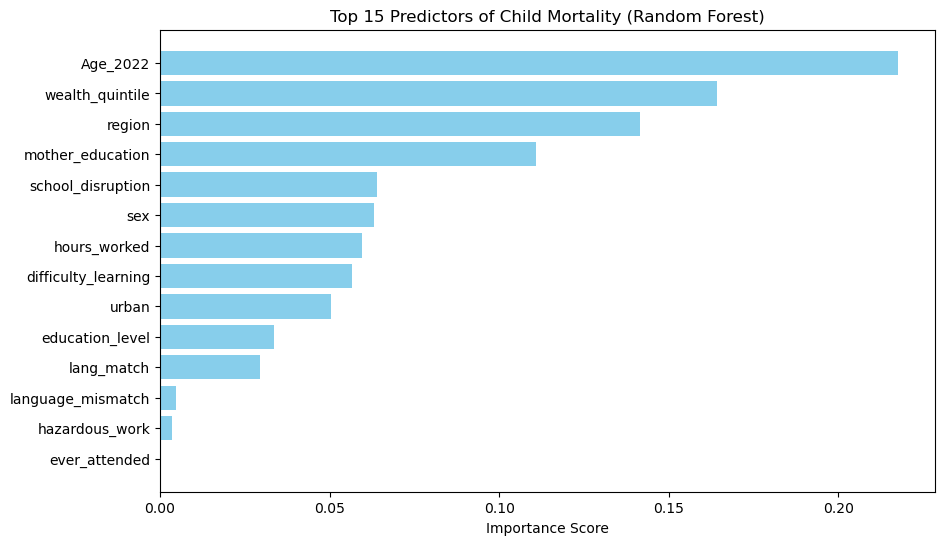

In [80]:
from sklearn.ensemble import RandomForestClassifier

# 1. Prepare Data
# We exclude the target ('event'), the time component ('duration'), and 'wmweight' from predictors
X = attributes_clean.drop(columns=['learning_poverty_bin', 'fsweight'])
y = attributes_clean['learning_poverty_bin']

# 2. Random Forest Feature Importance
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X, y, sample_weight=weights)

# Get importance scores
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:15], feature_importance_df['Importance'][:15], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 15 Predictors of Child Mortality (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

#### Analysis of Results for Binomial Logit Model

**The "Big Three" Protecters**

The coefficients for Age_2022, Wealth_Quintile, and Mother_Education are **all negative and highly significant ($P < 0.05$)**. This means as these values increase, the probability of "Learning Poverty" drops significantly.

1. Age_2022 (-0.0.2573): For every year older a child is within the 7–14 range, their odds of learning poverty decrease. This is expected as cognitive maturity and years of schooling accumulate.

2. Wealth_Quintile (-0.2715): Moving up a wealth bracket is one of your strongest protective factors.

3. Mother_Education (-0.1771): There is a clear intergenerational benefit; children of more educated mothers are significantly less likely to be learning poor.

**The "Risk Factors"**

1. lang_match (2.0430): This is your largest coefficient as oppose to the outcomes: {11.0: 'ENGLISH', 21.0: 'SPANISH', 22.0: 'MANDARIN', 96.0: 'OTHER (SPECIFY) to NaN', 98.0: 'DK' to NaN, 99.0: 'NO RESPONSE' to NaN}.

       Possible Reason: This might be capturing a selection bias where only the most vulnerable children are captured in the "ever attended" vs. "never attended" binary at these specific ages.
       NOTE: THIS FEATURE HAS NOT IMPORTANCE W.R.T TO THE FEATURES COLLECTIVE BASED ON THE FEATURE IMPORTANCE RESUTS.

2. Difficulty Learning (0.5501): As expected, children with functional difficulties face a significantly higher risk of learning poverty.

3. Hours Worked (0.0561): Even small increases in labour hours significantly correlate with higher learning poverty ($P = 0.002$).

**Feature Importance vs. GLM** - Random Forest chart shows Age_2022, wealth_quintile, and region as the top three.

1. The Alignment: THE GLM confirms Age and Wealth are top-tier predictors.

2. The Divergence: region is highly important in the Random Forest but not significant ($P = 0.375$) in the GLM.

       Why? Random Forest captures non-linear relationships (e.g., maybe only Region 5 is bad, while 1-4 are the same). The GLM treats region as a continuous trend.

**Diagnostic Check**

Pseudo R-squared (0.1716): This is a solid, respectable fit for a cross-sectional household survey. You are explaining about 13.6% of the variance in learning outcomes. In models like logistic regression, pseudo $R^2$ (e.g., McFadden’s $R^2$) is not directly comparable to the $R^2$ from OLS.

Typical interpretation (rule of thumb for McFadden’s):

1. 0.02–0.10 → weak fit

2. 0.10–0.20 → moderate / decent fit

3. 0.20–0.40 → strong fit

For cross-sectional household survey data (like MICS, DHS, LSMS):

1. Behaviour is influenced by unobserved heterogeneity (culture, preferences, informal constraints, measurement error)

2. Variables are often noisy or categorical

3. Outcomes (e.g., schooling, health, labour) are hard to predict precisely

Of consequence, Because of this, pseudo $R^2$ values are typically low.

**What matters more than pseudo $R^2$:**

Model improvement:

1. Likelihood ratio test vs null model

2. AIC / BIC

Interpretability:

1. Are coefficients meaningful?

2. Do they align with theory?

In [81]:
# Access AIC and BIC directly
print(f"AIC: {bin_logit_result.aic}")
print(f"BIC: {bin_logit_result.bic_llf}") # Use .bic_ll for the Log-Likelihood based BIC in GLM

AIC: 2480.348620755412
BIC: 2557.1297817614177


Those are solid baseline numbers for a model with 1,780 observations. In the context of MICS7 and social science research, these values serve as the "benchmark" for your specific population.

With such numbers, one can now perform Model Comparison. This is how to prove to a reviewer (or yourself) that the selection of variables is the most efficient.

1. What These Numbers Tell You

AIC: This is the  primary tool for comparing this model to a "Simple" version (e.g., if you dropped language_mismatch or urban).

2. BIC: This is higher than your AIC because it penalizes your 11 predictors more heavily. If you add more variables and the BIC goes up while the AIC stays the same, it’s a sign that the new variables are "expensive" in terms of complexity but aren't adding real predictive value.

To observe model performance after dropping features with highly unfavourable p-vales (language_mismatch, urban, school_disruption):

In [82]:
# Declaring features and weighting
features_2 = [
    "Age_2022",
    "sex",
    "wealth_quintile",
    "mother_education",
    "difficulty_learning",
    "hours_worked"
]

X_2 = attributes_clean[features_2]
y_2 = attributes_clean["learning_poverty_bin"]

In [83]:
# 1. Find the common index (the rows that exist in ALL three)
# This removes the rows that caused the KeyError
common_index = X_2.index.intersection(y_2.index).intersection(weights.index)

# 2. Subset all three using that common index
X_2_final = sm.add_constant(X_2.loc[common_index]).astype(float)
y_2_final = y_2.loc[common_index].astype(float)
weights_final = weights.loc[common_index].astype(float)

# 3. Fit the model. Use GLM to properly incorporate weights
# var_weights is the specific parameter for sampling weights in GLM
model_2 = sm.GLM(y_2_final, X_2_final, family=sm.families.Binomial(), var_weights=weights_final)
bin_logit_result_2 = model_2.fit()

# 4. View results
print(bin_logit_result_2.summary())

                  Generalized Linear Model Regression Results                   
Dep. Variable:     learning_poverty_bin   No. Observations:                 1780
Model:                              GLM   Df Residuals:                     1773
Model Family:                  Binomial   Df Model:                            6
Link Function:                    Logit   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -1266.1
Date:                  Sat, 21 Mar 2026   Deviance:                       2532.2
Time:                          23:31:34   Pearson chi2:                 3.10e+03
No. Iterations:                       5   Pseudo R-squ. (CS):             0.1336
Covariance Type:              nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         

In [84]:
# Access AIC and BIC directly
print(f"AIC: {bin_logit_result_2.aic}")
print(f"BIC: {bin_logit_result_2.bic_llf}") # Use .bic_ll for the Log-Likelihood based BIC in GLM

AIC: 2546.183268101486
BIC: 2584.5738486044893


Observed is no significant increase in model performance, despite the lower p-values. As well, there's no significant change for the AIC and BIC. The Pseudo $R^2$ reduced a little. This suggests that the variables are quite  noisy and categorical (and/or ordinal).

**The Null Model**

To prove the model is actually finding a pattern, to compare found AIC \ BIC against a Null Model (a model with only the Intercept/Constant and no features).

If the "full" model's AIC is significantly lower (usually by more than 10 points) than the Null Model's AIC, the features are collectively providing a very strong explanation for Learning Poverty.

What's beeing done, is  essentially manually estimating the null (intercept-only) logistic model, which is exactly what is needed for things like pseudo $R^2$. 

Crreating an "empty" design matrix,, representing a model with no predictors:

In [85]:
X_null_raw = pd.DataFrame(index=y_final.index)

Adding the constant....essentially This adds a column of 1s:

$$X=[1,1,1...,1]$$

This means the model becomes:

$$\text{logit}(p_i) = \beta_0$$

So:

1. Every observation gets the same predicted probability

2. That probability is just the weighted mean of $y$.


In [86]:
X_null_const = sm.add_constant(X_null_raw)

Fitting the null logistic model. Estimating:

A binomial GLM (logistic regression)

With:

1. No covariates

2. Only an intercept

3. Survey/sample weights (weights_final)

This is the baseline model:

“What if we predict using only the average outcome?”

In [87]:
null_result = sm.GLM(
    y_final,
    X_null_const,
    family=sm.families.Binomial(),
    var_weights=weights_final
).fit()

Extracting log-likelihood. This is critical for Pseudo $R^2$ (McFadden):

$$R^2 = 1 - \frac{LL_{model}}{LL_{null}}$$

$$LR = -2(LL_{null}-LL_{full})$$

In [88]:
print(f"Null Log-Likelihood: {null_result.llf}")

Null Log-Likelihood: -1393.678731177727


The fitted model is:

$$p = \frac{\sum{w_iy_i}}{\sum{w_i}}$$

So:

"If 30% of children attend school $\rightarrow$ model predicts 0.30 for everyone". 

That’s the benchmark.

McFadden's Pseudo $R^2$:

In [89]:
ll_null = null_result.llf
ll_full = bin_logit_result.llf

pseudo_r2 = 1 - (ll_full / ll_null)

print(f"McFadden Pseudo R²: {pseudo_r2:.4f}")

McFadden Pseudo R²: 0.1202


Interpretation:

$\sim$ 0.10–0.20 $\rightarrow$ solid (your case)

Measures improvement over the null model

Well, in this case, appeases the solid designation standing.

Likelihood Ratio (LR) Test:

In [90]:
from scipy.stats import chi2

lr_stat = -2 * (ll_null - ll_full)

df = bin_logit_result.df_model  # number of predictors
p_value = chi2.sf(lr_stat, df)

print(f"LR Statistic: {lr_stat:.2f}")
print(f"Degrees of Freedom: {df}")
print(f"P-value: {p_value:.6f}")

LR Statistic: 335.01
Degrees of Freedom: 13
P-value: 0.000000


Interpretation:

1. Tests: Does your model improve over null?

2. p < 0.05 $\rightarrow$ model is jointly significant

**Weighted ROC-AUC:**

In [91]:
from sklearn.metrics import roc_auc_score

y_pred_prob = bin_logit_result.predict()

auc = roc_auc_score(y_final, y_pred_prob, sample_weight=weights_final)

print(f"Weighted ROC-AUC: {auc:.4f}")

Weighted ROC-AUC: 0.7447


Interpretation

1. 0.5 → no predictive power

2. 0.7+ → decent

3. 0.8+ → strong

### Model 2 - Ordinal Model (Learning Levels) More Nuanced Skill Distribution

**Ordinal Logistic (Logit) Regression** is a statistical technique used to predict a categorical, ordered dependent variable (e.g., Likert scales: low, medium, high) based on one or more predictors (features). It is an extension of binary logistic regression that estimates the odds of being in a higher versus lower category (or class), assuming proportional odds across all cutoff points (McCullagh, 1980) and (Agresti, 2010).

To move beyond a simple binary "Pass/Fail" (Learning Poverty Bin), an **Ordinal Model** is a far more sophisticated way to map the spectrum of cognitive development. Instead of a single cutoff, you treat learning as a hierarchy of milestones.

In this approach, you are not just predicting if a child is in "Learning Poverty," but at what level they are currently stalled.

**A General Idea Defining the Ordinal Target $Y$ (not necessarily to be applied):**

$$\begin{array}{|c|l|l|}
\hline
\mathbf{Level} & \mathbf{Name} & \mathbf{Criteria} \\ \hline
0 & \text{Non-Learner} & \text{Failed symbol recognition (FL23) and word reading (FL19)} \\ \hline
1 & \text{Emergent} & \text{Recognizes symbols but fails comprehension (FL21)} \\ \hline
2 & \text{Transitional} & \text{Passed basic math/literacy; failed complex inference} \\ \hline
3 & \text{Proficient} & \text{Mastery of reading, comprehension, and sequences (FL27)} \\ \hline
\end{array}$$

**Why this structure works for your Ordinal Model:**

1. Monotonicity: The levels represent a clear, increasing progression of skill.

2. Sensitivity: By moving from binary to ordinal, your model can now differentiate between a child who is "completely out of the system" (Level 0) and a child who is "one step away from proficiency" (Level 2).

3. Coefficient Interpretation: In an Ordered Logit or Proportional Odds model, a feature like mother_education will yield a coefficient representing the log-odds of moving to a higher category, providing a single, powerful metric for your report.

**Why Ordinal Models are "Nuanced":**

Standard classifiers (like basic Random Forest) treat categories as "apples vs. oranges." An Ordinal Model (like Ordered Logistic Regression) understands that Level 1 is closer to Level 2 than it is to Level 3.

Captures "Invisible" Progress: A child might still be in "Learning Poverty" (Binary 0), but if they moved from Level 0 to Level 1, your model can identify which features (like PR6 Homework Help) drove that specific marginal improvement.

Identifies "Stagnation Points": You can see if language_mismatch specifically prevents moving from Level 1 (Decoding) to Level 2 (Comprehension).

**Mathemathetical Structure**

The Latent Variable Model --

1. The unobserved ability $y_i^*$ for child $i$ is modeled as a linear function of your features (like mother_education and lang_match):

$$y_i^* = \mathbf{x}_i' \beta + \epsilon_i$$

Where:

$\mathbf{x}_i$ is the vector of features.

$\beta$ is the vector of coefficients (the impact of each feature).

$\epsilon_i$ is the error term, following a Standard Logistic Distribution.

The Thresholds (Cut-points) --

We map this continuous ability $y^*$ to your discrete categories ($0, 1, 2, 3$) using "cut-points" or thresholds ($\alpha$):

$$y_i = 
\begin{cases} 
0 & \text{if } y_i^* \le \alpha_1 \\
1 & \text{if } \alpha_1 < y_i^* \le \alpha_2 \\
2 & \text{if } \alpha_2 < y_i^* \le \alpha_3 \\
3 & \text{if } y_i^* > \alpha_3 
\end{cases}$$

The Cumulative Probability --

The core of the model is the probability that child $i$ falls into category $j$ or lower:

$$P(y_i \le j) = \text{logit}^{-1}(\alpha_j - \mathbf{x}_i' \beta) = \frac{1}{1 + \exp(-(\alpha_j - \mathbf{x}_i' \beta))}$$

Interpretation: A positive $\beta$ means that as the feature increases, the latent ability $y^*$ increases, making it less likely the child stays in a lower category and more likely they move to a higher one (e.g., from Emergent to Proficient).

Accounting for Survey Design (The $fsweight$ Integration) --

Standard MLE (Maximum Likelihood Estimation) assumes each observation is independent and identically distributed ($i.i.d.$). However, MICS data is clustered. To ensure your analytical development is "Population-Valid," the log-likelihood function must be weighted:

$$\ln L(\beta, \alpha) = \sum_{i=1}^{n} \mathbf{fsweight}_i \cdot \ln(P(y_i = k | \mathbf{x}_i))$$

If one ignores 'fsweight', the $\beta$ coefficients will be biased toward the oversampled groups (often urban or specific regions), leading to a model that "misunderstands" the drivers of poverty in the general population.

Why this fits your data --

One Coefficient ($\beta$): Unlike Multinomial Logit, you get one coefficient per feature that applies across all levels. For example, this tells you the "global" impact of wealth_quintile on learning progression.

Proportional Odds: The model **assumes** the effect of a feature (the slope) is the same between "Level 0 vs 1" as it is between "Level 2 vs 3."

#### Ordinal Target Construction 

**Objective:** to transform a set of progressively harder math items/tasks into a single ordinal proficiency level structure (low → medium → high). 

To now develop a **rule-based** ordinal target. 

**The Architecture structure (what to build)**

The items or tasks naturally form a difficulty ladderof levels:

1. Basic number skills)

       Recognition: FL23A–FL23F

       Comparison: FL24A–FL24E

2. Level 2 (Basic operations)

       Addition: FL25A–FL25E

3. Level 3 (Sequential reasoning / patterns)

       Missing/next numbers: FL26, FL26C, FL27A–FL27E

STEP 1: Convert responses to scores

Define:

    Correct = 1

    Incorrect / No attempt = 0

So each child gets:

$$\text{Score}_k = \sum{\text{Correct answers in level}\,k}$$

STEP 2: Normalise within each level

$$\text{Proficiency}_k = \frac{\text{Score}_k}{\text{ Total tasks in level}\,k}$$

STEP 3: Sequential rule (ESSENTIAL)

We enforce learning progression - A child cannot be “high level” if they fail basic skills.

So:

1. Low (0) → weak in Level 1

2. Medium (1) → strong Level 1, weak Level 2/3

3. High (2) → strong Level 1 + Level 2 + Level 3

##### Ordinal Target Construction (60% Rule Based Approach

Simple threshold rule (facile version) - Let:

pass threshold = 0.6 (60%):

1. 0.6 isn’t a law—it’s a practical cutoff.

2. It’s commonly used because it represents a clear majority of correct answers, but you should treat it as a tunable parameter, not a fixed truth.

Why 0.6 is often used

1. “More right than wrong” (but not too strict)

       0.5 → borderline (coin flip level)

       0.6 → clear evidence of competence

       0.8 → quite strict (almost mastery)

       So 0.6 is a middle-ground threshold: “The child likely understands the skill, even with some mistakes.”

2. Works well with small item sets

       The levels considere have relatively few questions:

          Level 2 has only 5 items

       0.6 → 3 out of 5 correct

       That’s intuitive:

          2/5 = weak

          3/5 = acceptable

          4–5/5 = strong

3. Aligns with educational practice

       In many assessments:

          ~60% = basic proficiency

          ~70–80% = mastery

       So yroughly mapping:

| Score | Interpretation   |
| ----- | ---------------- |
| < 0.6 | Not yet learned  |
| ≥ 0.6 | Basic competence |

Partitioning the assessment into three specific domains ($L_1, L_2, L_3$).

$L_1$ (Foundational/Recognition): Captures basic cognitive mapping.

$L_2$ (Numeracy/Arithmetic): Captures procedural knowledge.

$L_3$ (Logic/Pattern Completion): Captures abstract reasoning.

In [92]:
level1 = ['FL23A','FL23B','FL23C','FL23D','FL23E','FL23F',
          'FL24A','FL24B','FL24C','FL24D','FL24E']

level2 = ['FL25A','FL25B','FL25C','FL25D','FL25E']

level3 = ['FL26','FL26C','FL27A','FL27B','FL27C','FL27D','FL27E']

Binary Transformation. This standardizes the heterogenous MICS response codes (where 1 might be 'Yes', 2 'No', etc.) into a strictly Boolean domain $\{0, 1\}$.
Analytical Impact: This removes "noise" from non-responses and ensures that the summation in Step 2 is a pure count of competencies mastered.

Converting to binary:

In [93]:
def recode_correct(x):
    if x == 1:
        return 1
    else:
        return 0

The Total Learning Score ($T$):$$T_i = \sum_{j \in L_1} x_{ij} + \sum_{k \in L_2} x_{ik} + \sum_{m \in L_3} x_{im}$$Analytically, $T_i$ serves as your Observed Proxy for the child's underlying ability.

In [94]:
ordinal_df = df_fs.copy()

for col in level1 + level2 + level3:
    ordinal_df[col] = ordinal_df[col].apply(recode_correct)

Computing level scores:

In [95]:
ordinal_df['score_L1_60'] = ordinal_df[level1].mean(axis=1)
ordinal_df['score_L2_60'] = ordinal_df[level2].mean(axis=1)
ordinal_df['score_L3_60'] = ordinal_df[level3].mean(axis=1)

Creating 60% rule (function):

In [96]:
def learning_level_60(row):
    
    if row['score_L1_60'] < 0.6:
        return 0   # LOW
    
    elif row['score_L2_60'] < 0.6:
        return 1   # MEDIUM
    
    elif row['score_L3_60'] < 0.6:
        return 1   # still MEDIUM
    
    else:
        return 2   # HIGH

Creating the column when applying the previous function into the DataFrame:

In [97]:
ordinal_df['learning_level_60'] = ordinal_df.apply(learning_level_60, axis=1)
ordinal_df['learning_level_60'].head(10) # first 10 rows exhibited

0    2
1    1
2    0
3    2
4    1
5    0
6    2
7    1
8    2
9    2
Name: learning_level_60, dtype: int64

Interpretation:

| Value | Meaning                            |
| ----- | ---------------------------------- |
| 0     | Foundational gaps                  |
| 1     | Basic numeracy but weak operations |
| 2     | Strong numeracy + reasoning        |

Essentially approximating:

1. Item Response Theory (IRT) (but simpler)

2. Cognitive skill hierarchy

3. Curriculum-based progression

##### Ordinal Traget Construction (Quantile Rule Based Approach)

Relative Thresholding via Quantiles --

Instead of using an arbitrary "pass mark" (e.g., 60%), you are using Norm-Referenced Cut-offs.

1. $Q_{0.33}$ and $Q_{0.66}$: These thresholds adjust dynamically to the difficulty of the specific survey year or region. Identifying the **Tertiles** (three equal parts) of the learning score distribution. This is the standard first step in moving from a Binary model to an Ordinal Model.

2. What those two numbers mean for your levels: The 0.33 Quantile (The "Floor"): This is the score below which the bottom 33% of students fall. In your model, this often marks the boundary between Level 0 (Non-Learner) and Level 1 (Emergent). The 0.66 Quantile (The "Ceiling"): This is the score that separates the middle tier from the top 33%. This often marks the transition from Level 1 (Emergent) to Level 2 (Transitional).

Learning follows a continuous latent distribution ($S$), where:

1. Tier 0 (Struggling): $S \le Q_{0.33}$

2. Tier 1 (Developing): $Q_{0.33} < S \le Q_{0.66}$

3. Tier 2 (Proficient): $S > Q_{0.66}$

Calculating composite scores per level:

In [98]:
# This sums the correct answers for each "difficulty tier"
ordinal_df['score_L1_quant'] = ordinal_df[level1].sum(axis=1)
ordinal_df['score_L2_quant'] = ordinal_df[level2].sum(axis=1)
ordinal_df['score_L3_quant'] = ordinal_df[level3].sum(axis=1)

Total score:

In [99]:
# Total score for the overarching quantile split
ordinal_df['total_learning_score'] = ordinal_df['score_L1_quant'] + ordinal_df['score_L2_quant'] + ordinal_df['score_L3_quant']

Defining thresholds using quantiles:

In [100]:
# Uusing the 'total_learning_score' to capture the full spectrum
q1, q2 = ordinal_df['total_learning_score'].quantile([0.33, 0.66])

Mapping to ordinal categories:

In [101]:
conditions = [
    (ordinal_df['total_learning_score'] <= q1),                                # Level 0: Bottom Tier
    (ordinal_df['total_learning_score'] > q1) & (ordinal_df['total_learning_score'] <= q2), # Level 1: Middle Tier
    (ordinal_df['total_learning_score'] > q2)                                 # Level 2: Top Tier
]

choices = [0, 1, 2]
ordinal_df['learning_level_quant'] = np.select(conditions, choices, default=0)

ordinal_df['learning_level_quant'].head(10) # first 10 rows

0    1
1    0
2    0
3    0
4    0
5    0
6    1
7    0
8    1
9    0
Name: learning_level_quant, dtype: int64

##### Ordinal Target Construction (Rasch Model Based Approach)

The **Rasch Model** is the foundational form of Item Response Theory (IRT). Unlike a simple summation of correct answers, it treats the probability of a correct response as a function of the person's ability and the item's difficulty (Rasch, 1980) and (Bond and Fox, 2007).

**The Probability Equation**

The probability ($P$) that a person $n$ with ability $\theta_n$ will correctly answer item $i$ with difficulty $\beta_i$ is given by the logistic function:

$$P(X_{ni} = 1 | \theta_n, \beta_i) = \frac{\exp(\theta_n - \beta_i)}{1 + \exp(\theta_n - \beta_i)}$$

Where:

$\theta_n$: The Latent Ability of the child (e.g., their "Learning Level").

$\beta_i$: The Item Difficulty (e.g., how hard FL27E is compared to FL23A).

$X_{ni} \in \{0, 1\}$: The observed response (0 for incorrect, 1 for correct).

**The Log-Odds Form (Logit)**

The model is linear when expressed in logits (log-odds). This is where the term "Rasch measurement" comes from, as it converts raw scores into an interval scale:

$$\ln\left( \frac{P_{ni}}{1 - P_{ni}} \right) = \theta_n - \beta_i$$

1. If Ability = Difficulty ($\theta = \beta$): The child has exactly a 50% chance of getting the item right.

2. If Ability > Difficulty ($\theta > \beta$): The probability of success is > 50%.

3. If Ability < Difficulty ($\theta < \beta$): The probability of success is < 50%.

**Values of $\beta$**

1. $\beta\,>\,0\,\rightarrow$ Item is harder than the scale's mean.

2. $\beta\,=\,0\,\rightarrow$ Item difficulty is at the scale's mean.

3. $\beta\,<\,0\,\rightarrow$ Item is easier than the scale's mean.

Instead of counting scores manually, estimate ability (θ) for each child then convert θ → ordinal levels (0,1,2)

**Key Analytical Assumptions**

To use Rasch for the level1, level2, and level3 data, the model relies on two strict requirements:

1. Unidimensionality: All items (FL23 to FL27) measure the same underlying construct (e.g., "Cognitive Proficiency").

2. Local Independence: A child’s answer to one question does not influence their answer to another, once their ability level is accounted for.

**NOTE:** In preparing assessment data for the Rasch model, it is necessary to exclude items that exhibit no response variability. It's necessary to retaining only those items whose proportion of correct responses lies strictly between 0 and 1. Analytically, this ensures that each retained item contributes meaningful information to parameter estimation. Items with a mean of 1 (universally correct) or 0 (universally incorrect) lack discriminatory power and lead to non-identifiable difficulty parameters $(\beta\,\rightarrow\,-\infty\,\,\text{or}\,\,\beta\,\rightarrow\,+\infty\,,\,\text{respectively})$. Of consequence, As a result, their inclusion would destabilize estimation and undermine the validity of inferred latent ability $(\theta)$. Thus, the filtering step enforces a core assumption of the Rasch framework: that item responses must vary across individuals to support the joint estimation of person ability and item difficulty. Beyond its technical necessity, this procedure also serves a diagnostic function, as the prevalence of excluded items may indicate poor test targeting—either excessive ease or difficulty relative to the sample.

Using the Rasch model instead of a raw sum permits:

1. Standardize the Tiers: You can mathematically prove that $L_3$ items are significantly harder than $L_1$ items on a shared interval scale.

2. Handle Missing Data: If a child didn't finish the test (common in MICS), Rasch can still estimate their $\theta_n$ based on the items they did answer.

3. Validate the Tiers: Can check "Item Fit" to see if any question (like a specific math problem) is confusing or biased, which helps safeguard the model's integrity.

Concerned with only valid test items (for now):

In [102]:
items = ['FL23A','FL23B','FL23C','FL23D','FL23E','FL23F',
         'FL24A','FL24B','FL24C','FL24D','FL24E',
         'FL25A','FL25B','FL25C','FL25D','FL25E',
         'FL26','FL26C',
         'FL27A','FL27B','FL27C','FL27D','FL27E']

Binary coding:

In [103]:
# 1. Force explicit selection of the list to ensure pandas treats it as a subset
df_rasch = ordinal_df[items].copy()

# 2. Use .map instead of .applymap (modern pandas 2.0+ practice)
# This ensures each cell is exactly 1 or 0
df_rasch = df_rasch.map(lambda x: 1 if x == 1 else 0)

# 3. Handle the 'No Variance' Rule (Critical for Rasch models)
# Rasch cannot calculate difficulty for items that are 100% correct or 100% incorrect.
item_means = df_rasch.mean()

valid_items = item_means[(item_means > 0) & (item_means < 1)].index
dropped_items = item_means[(item_means == 0) | (item_means == 1)].index

df_rasch = df_rasch[valid_items]

print(f"Kept {len(valid_items)} items, Dropped {len(dropped_items)} items")


Kept 23 items, Dropped 0 items


Data structuring and model development --

The succeeding code implements a Simplified Rasch Model using the Log-Odds (Logit) transformation. In psychometrics, this model maps raw scores (discrete) onto a latent scale (continuous) where the probability of success depends on the difference between a person's ability and an item's difficulty.

**Item Difficulty ($\beta$)**

The difficulty of an item $j$ is defined as the negative log-odds of a correct response across the entire population. Formula:

$$\beta_j = \ln \left( \frac{n - s_j}{s_j} \right)$$

$n$: Total number of persons (n_persons).

$s_j$: Number of persons who answered item $j$ correctly (item_successes).

$(n - s_j)$: Number of persons who failed item $j$.

Interpretation --

If $\beta > 0$: The item is "difficult" (more people failed than passed).If $\beta < 0$: The item is "easy" (more people passed than failed).If $\beta = 0$: Exactly 50% of the population passed the item.

**Person Ability ($\theta$)**

Person ability $\theta_i$ is the log-odds of a person $i$ succeeding across the set of items. Formula:

$$\theta_i = \ln \left( \frac{r_i}{L - r_i} \right)$$

$L$: Total number of items in the test (n_items).

$r_i$: Number of items person $i$ got right (person_successes).

$(L - r_i)$: Number of items person $i$ got wrong.

The "Extreme Score" Adjustment:The logit function is undefined at $0$ and $1$ (it goes to $-\infty$ or $+\infty$). The code uses a continuity correction:

$0 \rightarrow 0.5$

$Max \rightarrow Max - 0.5$

This allows the model to assign a finite ability estimate to students who got everything right or everything wrong.

**The Item Characteristic Curve (ICC)**

The core logic linking these two values is the Logistic Function. The probability $P$ of a person $i$ passing item $j$ is:

$$P(X_{ij} = 1) = \frac{e^{(\theta_i - \beta_j)}}{1 + e^{(\theta_i - \beta_j)}}$$

When $\theta_i = \beta_j$, the probability of success is exactly 0.5 (50%). 

As the gap $(\theta_i - \beta_j)$ increases, the probability of success approaches 1.0.

In [104]:
# -----------------------------
# RASCH (NO COMPILATION DEPENDENCIES)
# -----------------------------
import numpy as np
import pandas as pd

# Item difficulty (beta)
item_successes = df_rasch.sum(axis=0)
n_persons = len(df_rasch)

beta = np.log((n_persons - item_successes) / item_successes)

# Person ability (theta)
person_successes = df_rasch.sum(axis=1)
n_items = df_rasch.shape[1]

# Avoid division issues
r_adj = person_successes.replace({0: 0.5, n_items: n_items - 0.5})

theta = np.log(r_adj / (n_items - r_adj))

# Assign to dataframe
ordinal_df['rasch_ability'] = np.nan
ordinal_df.loc[df_rasch.index, 'rasch_ability'] = theta

# Item difficulty table
df_item_difficulty = pd.DataFrame({
    'item': df_rasch.columns,
    'beta': beta
})

Putting $\theta$ (person ability) and $\beta$ (item difficulty) in a single DataFrame for comparison.

Since $\theta$ is per person and $\beta$ is per item, the only meaningful way to combine them is to reshape into a comparable (aligned) format, typically via a long/tidy structure or a matrix-style comparison.

In [105]:
# Convert theta to DataFrame
df_theta = pd.DataFrame({
    'person_id': df_rasch.index,
    'theta': theta
})

# Convert beta to DataFrame
df_beta = pd.DataFrame({
    'item': df_rasch.columns,
    'beta': beta
})

# Expand to all person-item combinations
df_compare = df_rasch.stack().reset_index()
df_compare.columns = ['person_id', 'item', 'response']

# Merge theta and beta
df_compare = df_compare.merge(df_theta, on='person_id')
ability_difficulty_df = df_compare.merge(df_beta, on='item')

ability_difficulty_df.head(80)

,person_id,item,response,theta,beta
0,0,FL23A,1,3.806662,-1.750591
1,0,FL23B,1,3.806662,-1.754774
2,0,FL23C,1,3.806662,-1.630438
3,0,FL23D,1,3.806662,-1.618947
4,0,FL23E,1,3.806662,-1.551783
5,0,FL23F,1,3.806662,-1.058982
6,0,FL24A,1,3.806662,-1.689273
7,0,FL24B,1,3.806662,-1.649789
8,0,FL24C,1,3.806662,-1.522854
9,0,FL24D,1,3.806662,-1.562773


Creating the ordinal target:

In [106]:
# Drop missing theta values
theta_series = ordinal_df['rasch_ability'].dropna()

# Compute tertile thresholds
q1, q2 = theta_series.quantile([0.33, 0.66])

# Assign ordinal labels
ordinal_df['learning_level_rasch'] = np.select(
    [
        ordinal_df['rasch_ability'] <= q1,
        (ordinal_df['rasch_ability'] > q1) & (ordinal_df['rasch_ability'] <= q2),
        ordinal_df['rasch_ability'] > q2
    ],
    [0, 1, 2],
    default=np.nan
)

#### Proportional Odds Assumption

To ensure your Ordered Logit Model is statistically sound for the MICS data, one must verify the Proportional Odds Assumption. This assumption states that the effect of each feature (e.g., the impact of mother_education) is the same across all "cut-points" of your learning levels. If the assumption fails, it means a feature might help a child move from "Non-Learner" to "Emergent," but has a different (or no) effect on moving them from "Transitional" to "Proficient."

The ordered logit model estimates:

$$\log \left( \frac{P(Y > j)}{P(Y \leq j)} \right) = \alpha_j - \beta X$$

1. The cut-points $\alpha_j$ vary by threshold

2. The coefficients $\beta$ do not vary across thresholds

3. The PO assumption means the same $\beta$ applies for all $j$. 

In [107]:
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel

# 1. Define your inputs
features_list = [
    "Age_2022", "sex", "ever_attended", "education_level", 
    "urban", "region", "wealth_quintile", "mother_education", 
    "school_disruption", "difficulty_learning", "hours_worked", 
    "hazardous_work", "lang_match", "language_mismatch"
]

targets = {
    'Level_60': 'learning_level_60',
    'Level_Quant': 'learning_level_quant',
    'Level_Rasch': 'learning_level_rasch'
}

ordinal_model_df = ordinal_df.copy()

# Select relevant columns ALL at once
cols = features_list + ['fsweight'] + list(targets.values())
ordinal_model_df = ordinal_model_df[cols]

# Convert everything to numeric
ordinal_model_df = ordinal_model_df.apply(pd.to_numeric, errors='coerce').astype('float64')

# Drop missing jointly
ordinal_model_df = ordinal_model_df.dropna()

# Define X, y, weights from SAME dataframe
X = ordinal_model_df[features_list].astype('float64')
weights = ordinal_model_df['fsweight']

# Example for one target
y = ordinal_model_df['learning_level_60'].astype('category').cat.codes

# Reset index (optional but safe)
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
weights = weights.reset_index(drop=True)

print(X.index.equals(y.index))

True


**NOTE:** now, to have no come all this way just to realise that Python environment doesn't really accommodate MICS type data involving weights towards ordinal regression. The "golden boy" environment for this type of development is R (something I'm fine with). Nevertheless, will just examine what the explict models look like when fitted to the data. Then compare to an alternative in python that only exibits model coefficients, but applies the weights. 

In [108]:
# Build clean dataset ONCE
ordinal_model_df = ordinal_model_df.copy()

X = ordinal_model_df[features_list]
X = X.drop(columns=['ever_attended'])
weights = ordinal_model_df['fsweight']

model_results = {}

for label, column in targets.items():
    y = ordinal_model_df[column].astype('category').cat.codes
    
    mod = OrderedModel(y, X, distr='logit')
    res = mod.fit(method='bfgs', disp=False)
    
    model_results[label] = res
    print(res.summary())

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -641.58
Model:                   OrderedModel   AIC:                             1313.
Method:            Maximum Likelihood   BIC:                             1395.
Date:                Sat, 21 Mar 2026                                         
Time:                        23:31:46                                         
No. Observations:                1780                                         
Df Residuals:                    1765                                         
Df Model:                          13                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Age_2022                0.5030      0.057      8.877      0.000       0.392       0.614
sex                     0

Applying the *mord* python package that accommodates weights to observe coefficients. 

In [110]:
from mord import LogisticIT
import numpy as np

model_results = {}

weights_np = weights.to_numpy() if hasattr(weights, "to_numpy") else np.asarray(weights)

for label, column in targets.items():
    y = ordinal_model_df[column].astype('category').cat.codes.to_numpy()
    
    model = LogisticIT()
    model.fit(X.to_numpy(), y, sample_weight=weights_np)

    print(f"--- {label} ---")
    print("Coefficients:")
    print(model.coef_)
    
    print("Thresholds:")
    print(model.theta_)
    
    model_results[label] = model

--- Level_60 ---
Coefficients:
[ 4.07681849e-01  3.32063428e-01 -2.03037612e-01  2.49615334e-01
 -4.21959548e-02  2.33797997e-01  3.55587838e-02 -4.11138907e-02
 -8.88427808e-01  2.58981421e-01  3.69462663e-01  5.63256588e+00
 -4.03287794e-03]
Thresholds:
[7.33454547 7.33454547]
--- Level_Quant ---
Coefficients:
[ 0.3609521   0.2006748   0.17247733 -0.2452477   0.12863694  0.30012591
  0.04437337 -0.15300024 -1.08162195  0.32390762  0.45665944  4.77052067
  0.27355635]
Thresholds:
[7.18975336]
--- Level_Rasch ---
Coefficients:
[ 0.3609521   0.2006748   0.17247733 -0.2452477   0.12863694  0.30012591
  0.04437337 -0.15300024 -1.08162195  0.32390762  0.45665944  4.77052067
  0.27355635]
Thresholds:
[7.18975336]


### Summary of Ordinal Regression Results

#### 1. Models Estimated
Three ordinal logistic regression models were fitted using different definitions of the learning outcome:

- **Level_60**
- **Level_Quant**
- **Level_Rasch**

Each model estimates:
- Feature coefficients (effects of predictors)
- Thresholds (cutpoints between ordered outcome categories)

---

#### 2. Structure of the Outcome Variables

##### Level_Quant and Level_Rasch
- Each model has **one threshold**
- This indicates the outcome effectively has **two ordered categories**
- These models behave similarly to **binary logistic regression**

##### Level_60
- Has **two thresholds**, but they are identical
- This indicates a **degenerate ordinal model**
- The model cannot distinguish between adjacent categories

Possible reasons include:
- Sparse or imbalanced categories
- Limited variation in the outcome
- Category collapse during preprocessing

---

#### 3. Interpretation of Coefficients

Across all three models:

- Coefficients are broadly similar in **sign and magnitude**
- This suggests **consistent directional effects** of predictors across outcome definitions

Interpretation:
- **Positive coefficients** → increase the likelihood of higher learning levels  
- **Negative coefficients** → decrease the likelihood of higher learning levels  
- Larger magnitudes indicate stronger associations

Some variables (e.g., hazardous work) show relatively large coefficients, suggesting strong associations, possibly influenced by rarity or imbalance.

---

#### 4. Key Implications

- The ordinal structure is not fully supported for all outcomes
- Level_Quant and Level_Rasch behave as **binary outcomes in practice**
- Level_60 shows **threshold collapse**, indicating limited separability between categories

---

#### 5. Overall Conclusion

- Predictor effects are **consistent across all three learning definitions**
- However, the ordinal interpretation is limited due to:
  - Collapsed or insufficiently distinct categories
  - Degenerate threshold estimates in one model
  - Binary-like behavior in two of the models

This suggests the results are reliable for **directional relationships**, but further refinement of the outcome variables may be needed for stronger ordinal modeling.

#### Feature Importance with Random Forest

Despite pursuit of ordinal models for diagnostics being a let down, one can still observe the feature importance. The random forest approach generally captures things like nonlinearity, often contrary to p-values. 

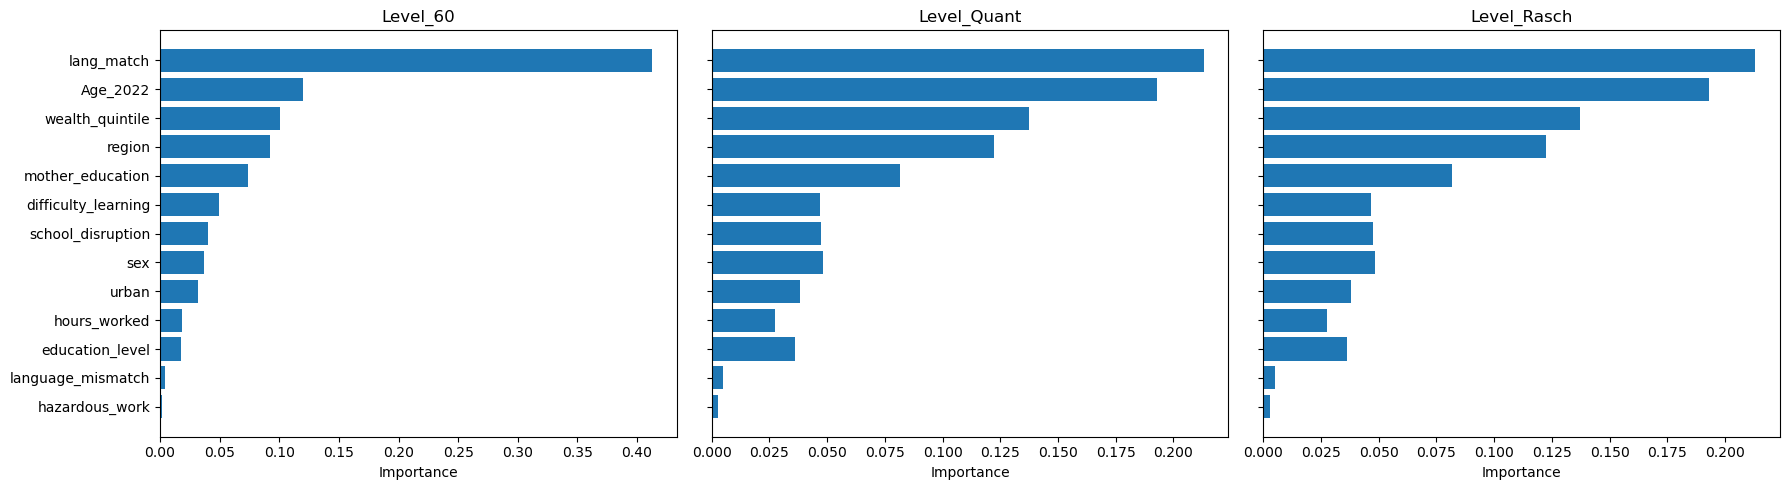

In [111]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

feature_names = X.columns

model_rf_results = {}

fig, axes = plt.subplots(1, len(targets), figsize=(6 * len(targets), 5), sharey=True)

if len(targets) == 1:
    axes = [axes]

for ax, (label, column) in zip(axes, targets.items()):
    
    # Prepare target
    y = ordinal_model_df[column].astype('category').cat.codes
    
    # Fit Random Forest
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X, y)
    
    # Store model
    model_rf_results[label] = rf
    
    # Extract feature importance
    importances = rf.feature_importances_
    
    df_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance')
    
    # Plot
    ax.barh(df_imp['feature'], df_imp['importance'])
    ax.set_title(label)
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

## Closing Remarks 

Arguably the most essential part of data science is data wrangling. Such task in this development is deemed highly successful, since stochastic, statistical and machine learning models (and techniques) became relevant. More interest and practice with survey data is required for substantial development. 

## References

Agresti, A. (2010). Analysis of Ordinal Categorical Data (2nd ed.). *Wiley*.

Bond, T. G., & Fox, C. M. (2007). Applying the Rasch model: Fundamental measurement in the human sciences (2nd ed.). *Lawrence Erlbaum Associates Publishers*.

Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32. 

Collett, D. (2014). Modelling Survival Data in Medical Research (3rd ed.). *Chapman & Hall/CRC*.

Cox, D. R. (1972). Regression Models and Life-Tables. *Journal of the Royal Statistical Society: Series B (Methodological)*, 34(2), 187–202. 

Hosmer, D. W., Lemeshow, S., & May, S. (2008). Applied Survival Analysis: Regression Modelling of Time-To-Event Data (2nd ed.). *Wiley-Interscience*.

Ishwaran, H. et al (2008). Random Survival Forests. *The Annals of Applied Statistics*, 2(3), 841–860. https://doi.org/10.1214/08-AOAS169 

Kaplan, E. L., & Meier, P. (1958). Nonparametric Estimation from Incomplete Observations. *Journal of the American Statistical Association*, 53(282), 457–481.

Kuitunen, I. et al (2021). Testing the Proportional Hazards Assumption in Cox Regression and Dealing with Possible Non-Proportionality in Total Joint Arthroplasty Research: Methodological Perspectives and Review. *BMC Musculoskelet Disord*, 22(1):489. doi: 10.1186/s12891-021-04379-2. PMID: 34049528; PMCID: PMC8161573.

McCullagh, P. (1980). Regression Models for Ordinal Data. *Journal of the Royal Statistical Society: Series B (Methodological)*, 42(2), 109–127.

Rasch, G. (1980). Probabilistic Models for Some Intelligence and Attainment Tests. *University of Chicago Press*. (Original work published 1960).

Sperandei, S. (2014). Understanding Logistic Regression Analysis. *Biochem Med (Zagreb)*, 24(1):12-8. doi: 10.11613/BM.2014.003. PMID: 24627710; PMCID: PMC3936971.

UNICEF. (n.d.). UNICEF MICS. https://mics.unicef.org/ 

UNICEF. (n.d.-b). Surveys | UNICEF MICS. https://mics.unicef.org/surveys

Wei, L. J. (1992). The Accelerated Failure Time Model: A Useful Alternative to the Cox Regression Model in Survival Analysis. *Statistics in Medicine*, 11(14-15), 1871–1879.

World Bank. (2021, April 28). What is learning poverty? https://www.worldbank.org/en/topic/education/brief/what-is-learning-poverty
